# Multi-Factor Equity Portfolio Backtester

This project constructs and evaluates a monthly rebalanced U.S. equity
portfolio using momentum, value, quality, and low-volatility factors.

The system ranks securities using point-in-time information, selects the
highest-scoring stocks, applies realistic transaction costs, and compares
performance against the SPDR S&P 500 ETF Trust (SPY).

## Main objectives

- Build a reproducible financial-data pipeline
- Prevent look-ahead bias
- Engineer quantitative equity factors
- Construct and backtest a systematic portfolio
- Measure risk-adjusted performance
- Produce professional investment-research visualizations

## Disclaimer

This notebook is an educational research project and does not constitute
investment advice.

## 1. Environment Setup

Install the external Python packages required for market-data collection and economic-data access.

In [1]:
# Install packages that may not already be available in Google Colab.
# The -q flag keeps the installation output concise.

%pip install -q yfinance pandas_datareader

In [2]:
# ============================================================
# CELL 2: IMPORTS AND NOTEBOOK SETTINGS
# ============================================================

from __future__ import annotations

import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from pandas_datareader import data as pdr
from scipy import stats
import statsmodels.api as sm


# Reduce non-critical warning clutter while keeping real errors visible.
warnings.filterwarnings("ignore", category=FutureWarning)

# Improve how tables appear inside Colab.
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Environment loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"yfinance version: {yf.__version__}")

Environment loaded successfully.
Pandas version: 2.2.2
NumPy version: 2.0.2
yfinance version: 0.2.66


## 2. Project Configuration and Investment Universe

Define the backtest period, portfolio rules, benchmark, transaction costs, and the initial 50-stock research universe.

The data-download period begins before the official backtest period because the momentum factor requires approximately twelve months of historical prices.

In [3]:
# ============================================================
# CELL 3: PROJECT CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class BacktestConfig:
    """Central configuration for the portfolio backtest."""

    # Download additional historical data for factor lookback periods.
    data_start: str = "2014-12-01"

    # Official period over which portfolio performance is evaluated.
    backtest_start: str = "2016-01-01"
    backtest_end: str = "2025-12-31"

    benchmark: str = "SPY"
    initial_capital: float = 100_000.0

    # Portfolio construction settings.
    number_of_holdings: int = 15
    rebalance_frequency: str = "ME"  # Month-end
    maximum_position_weight: float = 0.10

    # 10 basis points equals 0.10% per dollar traded.
    transaction_cost_bps: float = 10.0

    # Approximate trading-day conventions.
    annualization_factor: int = 252
    volatility_lookback_days: int = 63
    momentum_skip_days: int = 21
    momentum_lookback_days: int = 252


CONFIG = BacktestConfig()


# Diversified research universe containing 50 large, liquid U.S. equities.
UNIVERSE = [
    # Information technology
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL", "CRM", "ADBE", "CSCO",

    # Communication services
    "GOOGL", "META", "NFLX", "DIS", "CMCSA",

    # Consumer discretionary
    "AMZN", "TSLA", "HD", "MCD", "NKE", "LOW", "SBUX",

    # Consumer staples
    "WMT", "COST", "PG", "KO", "PEP",

    # Health care
    "UNH", "JNJ", "LLY", "MRK", "ABBV", "TMO", "AMGN",

    # Financial services
    "JPM", "BAC", "WFC", "GS", "MS", "V", "MA",

    # Industrials
    "CAT", "GE", "HON", "UPS", "RTX",

    # Energy
    "XOM", "CVX", "COP",

    # Utilities
    "NEE", "DUK",

    # Real estate
    "AMT",
]


# Validation checks fail early if the project settings are inconsistent.
assert len(UNIVERSE) == 50, "The research universe must contain exactly 50 stocks."
assert len(set(UNIVERSE)) == len(UNIVERSE), "Duplicate ticker symbols were found."
assert CONFIG.number_of_holdings <= len(UNIVERSE), (
    "The portfolio cannot hold more stocks than exist in the universe."
)
assert 0 < CONFIG.maximum_position_weight <= 1, (
    "Maximum position weight must be between 0 and 1."
)


print("Project configuration created successfully.")
print(f"Research universe: {len(UNIVERSE)} stocks")
print(f"Backtest period: {CONFIG.backtest_start} through {CONFIG.backtest_end}")
print(f"Benchmark: {CONFIG.benchmark}")
print(f"Portfolio holdings: {CONFIG.number_of_holdings}")
print(f"Starting capital: ${CONFIG.initial_capital:,.0f}")
print(f"Transaction cost: {CONFIG.transaction_cost_bps:.0f} basis points")

Project configuration created successfully.
Research universe: 50 stocks
Backtest period: 2016-01-01 through 2025-12-31
Benchmark: SPY
Portfolio holdings: 15
Starting capital: $100,000
Transaction cost: 10 basis points


## 3. Historical Price Data Pipeline

Download daily adjusted market prices for the 50-stock investment universe and the SPY benchmark.

This section:

- Requests historical prices from Yahoo Finance
- Handles temporary download failures
- Extracts adjusted closing prices
- Checks for missing or invalid observations
- Creates daily return series
- Performs a visual data-quality inspection

The download begins before the official backtest period because momentum and volatility factors require historical lookback data.

In [4]:
# ============================================================
# CELL 5: HISTORICAL PRICE DOWNLOAD FUNCTIONS
# ============================================================

import time
from collections.abc import Sequence


def extract_close_prices(
    downloaded_data: pd.DataFrame,
    ticker_hint: str | None = None,
) -> pd.DataFrame:
    """
    Extract the adjusted closing-price columns returned by yfinance.

    yfinance may return:
    1. MultiIndex columns for multiple tickers
    2. Standard columns for a single ticker
    3. Slightly different column ordering across package versions

    Because auto_adjust=True is used, the returned 'Close' field is the
    automatically adjusted closing price.

    Parameters
    ----------
    downloaded_data:
        Raw DataFrame returned by yfinance.
    ticker_hint:
        Ticker name used when downloading only one security.

    Returns
    -------
    pd.DataFrame
        Date-indexed adjusted closing prices with ticker symbols as columns.
    """

    if downloaded_data is None or downloaded_data.empty:
        return pd.DataFrame()

    data = downloaded_data.copy()

    if isinstance(data.columns, pd.MultiIndex):
        first_level = data.columns.get_level_values(0)
        second_level = data.columns.get_level_values(1)

        if "Close" in first_level:
            close_prices = data["Close"].copy()

        elif "Close" in second_level:
            close_prices = data.xs(
                "Close",
                axis=1,
                level=1,
            ).copy()

        else:
            raise ValueError(
                "Could not find a Close field in the downloaded MultiIndex data."
            )

    else:
        if "Close" not in data.columns:
            raise ValueError(
                "Could not find a Close column in the downloaded data."
            )

        close_prices = data["Close"].copy()

        if isinstance(close_prices, pd.Series):
            column_name = ticker_hint or "Close"
            close_prices = close_prices.to_frame(name=column_name)

    # Standardize ticker formatting.
    close_prices.columns = [
        str(column).strip().upper()
        for column in close_prices.columns
    ]

    # Standardize and clean the date index.
    close_prices.index = pd.to_datetime(close_prices.index)

    if close_prices.index.tz is not None:
        close_prices.index = close_prices.index.tz_localize(None)

    close_prices = close_prices[
        ~close_prices.index.duplicated(keep="first")
    ]

    return close_prices.sort_index()


def download_price_history(
    tickers: Sequence[str],
    start_date: str,
    end_date: str,
    maximum_retries: int = 3,
) -> pd.DataFrame:
    """
    Download adjusted daily closing prices for a collection of securities.

    The function first attempts one efficient batch download. Any missing
    securities are then retried individually.

    Parameters
    ----------
    tickers:
        Collection of Yahoo Finance ticker symbols.
    start_date:
        Inclusive download start date in YYYY-MM-DD format.
    end_date:
        Exclusive download end date in YYYY-MM-DD format.
    maximum_retries:
        Maximum number of individual download attempts for failed tickers.

    Returns
    -------
    pd.DataFrame
        Adjusted daily closing prices.

    Raises
    ------
    RuntimeError
        If one or more securities cannot be downloaded after all retries.
    """

    normalized_tickers = list(
        dict.fromkeys(
            str(ticker).strip().upper()
            for ticker in tickers
        )
    )

    if not normalized_tickers:
        raise ValueError("At least one ticker must be supplied.")

    if pd.Timestamp(start_date) >= pd.Timestamp(end_date):
        raise ValueError("The start date must occur before the end date.")

    print(
        f"Downloading {len(normalized_tickers)} securities "
        f"from {start_date} through {end_date}..."
    )

    try:
        raw_data = yf.download(
            tickers=normalized_tickers,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            actions=False,
            repair=True,
            progress=False,
            threads=True,
            group_by="column",
            timeout=30,
        )

        close_prices = extract_close_prices(raw_data)

    except Exception as error:
        print(f"Batch download failed: {error}")
        close_prices = pd.DataFrame()

    missing_tickers = [
        ticker
        for ticker in normalized_tickers
        if (
            ticker not in close_prices.columns
            or close_prices[ticker].dropna().empty
        )
    ]

    if missing_tickers:
        print(
            f"Retrying {len(missing_tickers)} missing ticker(s) individually: "
            f"{missing_tickers}"
        )

    for ticker in missing_tickers:
        ticker_prices = pd.DataFrame()

        for attempt in range(1, maximum_retries + 1):
            try:
                raw_ticker_data = yf.download(
                    tickers=ticker,
                    start=start_date,
                    end=end_date,
                    auto_adjust=True,
                    actions=False,
                    repair=True,
                    progress=False,
                    threads=False,
                    group_by="column",
                    timeout=30,
                )

                ticker_prices = extract_close_prices(
                    raw_ticker_data,
                    ticker_hint=ticker,
                )

                if not ticker_prices.empty:
                    break

            except Exception as error:
                print(
                    f"{ticker}: attempt {attempt} failed with "
                    f"{type(error).__name__}: {error}"
                )

            # Wait slightly longer after each failed attempt.
            time.sleep(attempt * 2)

        if not ticker_prices.empty:
            if ticker in ticker_prices.columns:
                close_prices[ticker] = ticker_prices[ticker]
            elif ticker_prices.shape[1] == 1:
                close_prices[ticker] = ticker_prices.iloc[:, 0]

    still_missing = [
        ticker
        for ticker in normalized_tickers
        if (
            ticker not in close_prices.columns
            or close_prices[ticker].dropna().empty
        )
    ]

    if still_missing:
        raise RuntimeError(
            "Price history could not be downloaded for: "
            + ", ".join(still_missing)
            + ". Wait briefly and rerun this cell."
        )

    close_prices = close_prices.reindex(columns=normalized_tickers)

    # Force all observations to numeric values.
    close_prices = close_prices.apply(
        pd.to_numeric,
        errors="coerce",
    )

    close_prices = close_prices.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    if (close_prices <= 0).any().any():
        invalid_columns = close_prices.columns[
            (close_prices <= 0).any()
        ].tolist()

        raise ValueError(
            "Non-positive prices were detected for: "
            + ", ".join(invalid_columns)
        )

    print("Price download completed successfully.")

    return close_prices

In [5]:
# ============================================================
# CELL 6: DOWNLOAD STOCK AND BENCHMARK PRICES
# ============================================================

# Add SPY to the 50-stock research universe.
ALL_TICKERS = UNIVERSE + [CONFIG.benchmark]

# yfinance treats the end date as exclusive. Adding one calendar day
# ensures that CONFIG.backtest_end is included when it is a trading day.
DOWNLOAD_END = (
    pd.Timestamp(CONFIG.backtest_end)
    + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")


raw_prices = download_price_history(
    tickers=ALL_TICKERS,
    start_date=CONFIG.data_start,
    end_date=DOWNLOAD_END,
)


# Forward-fill only short gaps. We do not backward-fill because doing so
# could insert prices before real observations existed.
prices = raw_prices.ffill(limit=3)


# Separate the investable stocks from the benchmark.
stock_prices = prices[UNIVERSE].copy()
benchmark_price = prices[CONFIG.benchmark].copy()


print()
print("Downloaded dataset summary")
print("-" * 50)
print(f"First observation: {prices.index.min().date()}")
print(f"Last observation:  {prices.index.max().date()}")
print(f"Trading dates:     {len(prices):,}")
print(f"Stock columns:     {stock_prices.shape[1]}")
print(f"Benchmark:         {benchmark_price.name}")
print(f"Total securities:  {prices.shape[1]}")

Price download completed successfully.

Downloaded dataset summary
--------------------------------------------------
First observation: 2014-12-01
Last observation:  2025-12-31
Trading dates:     2,788
Stock columns:     50
Benchmark:         SPY
Total securities:  51


In [6]:
# ============================================================
# CELL 7: PRICE DATA QUALITY REPORT
# ============================================================

def build_price_quality_report(
    price_data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Create a security-level data-quality report.

    The report records:
    - First available price date
    - Last available price date
    - Number of valid observations
    - Number and percentage of missing observations
    - Minimum and maximum observed adjusted prices
    """

    report = pd.DataFrame(index=price_data.columns)

    report.index.name = "Ticker"

    report["First Date"] = [
        price_data[column].first_valid_index()
        for column in price_data.columns
    ]

    report["Last Date"] = [
        price_data[column].last_valid_index()
        for column in price_data.columns
    ]

    report["Valid Observations"] = price_data.notna().sum()
    report["Missing Observations"] = price_data.isna().sum()

    report["Missing %"] = (
        price_data.isna().mean() * 100
    )

    report["Minimum Price"] = price_data.min()
    report["Maximum Price"] = price_data.max()

    return report.sort_values(
        "Missing %",
        ascending=False,
    )


price_quality_report = build_price_quality_report(prices)

display(price_quality_report.head(15))


securities_with_missing_data = price_quality_report[
    price_quality_report["Missing %"] > 0
]

print()
print(f"Securities with any missing values: "
      f"{len(securities_with_missing_data)}")

print(
    f"Highest missing-data percentage: "
    f"{price_quality_report['Missing %'].max():.4f}%"
)


if price_quality_report["Missing %"].max() > 5:
    print(
        "WARNING: At least one security has more than 5% missing data. "
        "Review the affected ticker before continuing."
    )
else:
    print("Data completeness is acceptable for the initial backtest.")


,First Date,Last Date,Valid Observations,Missing Observations,Missing %,Minimum Price,Maximum Price
Ticker,,,,,,,
AAPL,2014-12-01,2025-12-31,2788,0,0.0000,20.5659,285.6593
MSFT,2014-12-01,2025-12-31,2788,0,0.0000,34.2845,538.6586
NVDA,2014-12-01,2025-12-31,2788,0,0.0000,0.4587,206.7763
AVGO,2014-12-01,2025-12-31,2788,0,0.0000,6.8201,410.6686
ORCL,2014-12-01,2025-12-31,2788,0,0.0000,29.1186,325.7593
CRM,2014-12-01,2025-12-31,2788,0,0.0000,52.8752,363.2192
ADBE,2014-12-01,2025-12-31,2788,0,0.0000,69.7400,688.3700
CSCO,2014-12-01,2025-12-31,2788,0,0.0000,16.4876,79.3927
GOOGL,2014-12-01,2025-12-31,2788,0,0.0000,24.6346,322.8084



Securities with any missing values: 0
Highest missing-data percentage: 0.0000%
Data completeness is acceptable for the initial backtest.


In [7]:
# ============================================================
# CELL 8: DAILY RETURNS AND ANOMALY CHECKS
# ============================================================

# Simple daily return:
#
#     Return_t = Price_t / Price_(t-1) - 1
#
# We calculate this manually instead of allowing pandas to silently
# fill missing values before computing percentage changes.

daily_returns = (
    prices / prices.shift(1) - 1.0
)

stock_returns = daily_returns[UNIVERSE].copy()
benchmark_returns = daily_returns[CONFIG.benchmark].copy()


# Identify very large daily adjusted-price moves for manual inspection.
# These are not automatically deleted because they may be legitimate.
LARGE_MOVE_THRESHOLD = 0.40

large_move_mask = stock_returns.abs() > LARGE_MOVE_THRESHOLD

large_move_count = int(large_move_mask.sum().sum())


# Convert flagged observations into an easy-to-read table.
large_moves = (
    stock_returns.where(large_move_mask)
    .stack()
    .rename("Daily Return")
    .reset_index()
)

large_moves.columns = [
    "Date",
    "Ticker",
    "Daily Return",
]

large_moves["Absolute Return"] = (
    large_moves["Daily Return"].abs()
)

large_moves = large_moves.sort_values(
    "Absolute Return",
    ascending=False,
)


print("Return-series validation")
print("-" * 50)
print(f"Stock return matrix shape: {stock_returns.shape}")
print(f"Benchmark observations:    {benchmark_returns.notna().sum():,}")
print(f"Daily moves above ±40%:     {large_move_count}")


if large_moves.empty:
    print("No unusually large adjusted daily moves were detected.")
else:
    print()
    print("Largest flagged observations:")
    display(large_moves.head(10))

Return-series validation
--------------------------------------------------
Stock return matrix shape: (2788, 50)
Benchmark observations:    2,787
Daily moves above ±40%:     0
No unusually large adjusted daily moves were detected.


### Visual Price Inspection

Normalize a representative sample of securities to an initial value of 100.

Normalization makes securities with very different dollar prices directly comparable. It helps identify discontinuities, missing periods, or suspicious price behavior before the backtest is constructed.

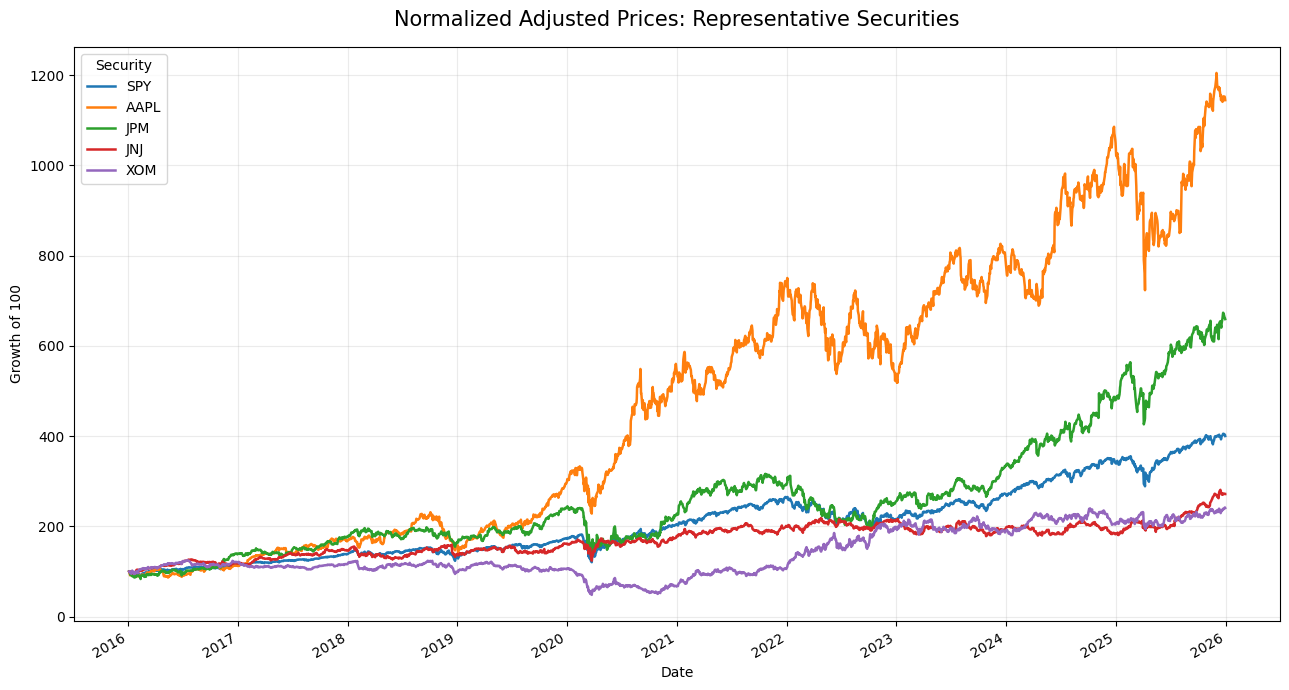

In [8]:
# ============================================================
# CELL 9: NORMALIZED PRICE SANITY-CHECK CHART
# ============================================================

SAMPLE_TICKERS = [
    CONFIG.benchmark,
    "AAPL",
    "JPM",
    "JNJ",
    "XOM",
]

sample_prices = (
    prices.loc[CONFIG.backtest_start:, SAMPLE_TICKERS]
    .dropna(how="all")
)


# Normalize each series to 100 on its first valid observation.
normalized_prices = sample_prices.copy()

for ticker in normalized_prices.columns:
    first_valid_price = normalized_prices[ticker].dropna().iloc[0]

    normalized_prices[ticker] = (
        normalized_prices[ticker]
        / first_valid_price
        * 100
    )


ax = normalized_prices.plot(
    figsize=(13, 7),
    linewidth=1.8,
)

ax.set_title(
    "Normalized Adjusted Prices: Representative Securities",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of 100")
ax.grid(True, alpha=0.25)
ax.legend(title="Security")

plt.tight_layout()
plt.show()

## 4. Monthly Rebalance Calendar and Technical Factors

The strategy evaluates stocks at the end of each calendar month.

Two factors are calculated in this section:

### 12–1 Momentum

Momentum measures each stock's return from approximately twelve months ago through one month ago:

\[
\text{Momentum}_{t} =
\frac{P_{t-21}}{P_{t-252}} - 1
\]

The most recent 21 trading days are skipped. Higher momentum is considered better.

### Low Volatility

Volatility is calculated using the standard deviation of daily returns over the previous 63 trading days:

\[
\sigma_{\text{annualized}} =
\sigma_{\text{daily}} \times \sqrt{252}
\]

Lower volatility is considered better.

Signals are calculated using month-end closing data. Portfolio changes will not take effect until the following trading day, which prevents same-day look-ahead bias.

In [9]:
# ============================================================
# CELL 11: MONTH-END REBALANCE CALENDAR
# ============================================================

def build_month_end_rebalance_dates(
    trading_index: pd.DatetimeIndex,
    start_date: str,
    end_date: str,
) -> pd.DatetimeIndex:
    """
    Find the final available trading date in every calendar month.

    Calendar month-end dates frequently occur on weekends or holidays.
    This function therefore uses the final date actually present in the
    market-price dataset.

    Parameters
    ----------
    trading_index:
        DatetimeIndex containing available market trading dates.
    start_date:
        First date of the official backtest.
    end_date:
        Final date of the official backtest.

    Returns
    -------
    pd.DatetimeIndex
        Last available trading date in each calendar month.
    """

    dates = pd.DatetimeIndex(trading_index)

    dates = (
        dates
        .drop_duplicates()
        .sort_values()
    )

    dates = dates[
        (dates >= pd.Timestamp(start_date))
        & (dates <= pd.Timestamp(end_date))
    ]

    if dates.empty:
        raise ValueError(
            "No trading dates were found inside the requested period."
        )

    # Group all trading dates by calendar month and retain the final one.
    date_series = pd.Series(
        data=dates,
        index=dates,
    )

    month_end_dates = date_series.groupby(
        dates.to_period("M")
    ).max()

    rebalance_dates = pd.DatetimeIndex(
        month_end_dates.to_numpy(),
        name="Signal Date",
    )

    return rebalance_dates


REBALANCE_DATES = build_month_end_rebalance_dates(
    trading_index=prices.index,
    start_date=CONFIG.backtest_start,
    end_date=CONFIG.backtest_end,
)


def find_next_trading_date(
    signal_date: pd.Timestamp,
    trading_index: pd.DatetimeIndex,
) -> pd.Timestamp:
    """
    Return the first trading date strictly after a signal date.

    A missing value is returned when the dataset contains no later date.
    """

    dates = pd.DatetimeIndex(trading_index).sort_values()

    next_position = dates.searchsorted(
        signal_date,
        side="right",
    )

    if next_position >= len(dates):
        return pd.NaT

    return dates[next_position]


# Create an auditable mapping between each signal date and the date on
# which the newly selected portfolio would begin earning returns.
REBALANCE_SCHEDULE = pd.DataFrame(
    {
        "Signal Date": REBALANCE_DATES,
        "Execution Date": [
            find_next_trading_date(
                signal_date=date,
                trading_index=prices.index,
            )
            for date in REBALANCE_DATES
        ],
    }
)

REBALANCE_SCHEDULE["Signal Month"] = (
    REBALANCE_SCHEDULE["Signal Date"]
    .dt.to_period("M")
    .astype(str)
)


print("Monthly rebalance calendar created successfully.")
print(f"Number of month-end signal dates: {len(REBALANCE_DATES)}")
print(f"First signal date: {REBALANCE_DATES.min().date()}")
print(f"Last signal date:  {REBALANCE_DATES.max().date()}")

print()
print("First five scheduled rebalances:")
display(REBALANCE_SCHEDULE.head())

print()
print("Final five scheduled rebalances:")
display(REBALANCE_SCHEDULE.tail())

Monthly rebalance calendar created successfully.
Number of month-end signal dates: 120
First signal date: 2016-01-29
Last signal date:  2025-12-31

First five scheduled rebalances:


,Signal Date,Execution Date,Signal Month
0,2016-01-29,2016-02-01,2016-01
1,2016-02-29,2016-03-01,2016-02
2,2016-03-31,2016-04-01,2016-03
3,2016-04-29,2016-05-02,2016-04
4,2016-05-31,2016-06-01,2016-05



Final five scheduled rebalances:


,Signal Date,Execution Date,Signal Month
115,2025-08-29,2025-09-02,2025-08
116,2025-09-30,2025-10-01,2025-09
117,2025-10-31,2025-11-03,2025-10
118,2025-11-28,2025-12-01,2025-11
119,2025-12-31,NaT,2025-12


In [10]:
# ============================================================
# CELL 12: MOMENTUM AND VOLATILITY FACTOR FUNCTIONS
# ============================================================

def calculate_12_1_momentum(
    price_data: pd.DataFrame,
    lookback_days: int = 252,
    skip_days: int = 21,
) -> pd.DataFrame:
    """
    Calculate the 12-1 price momentum factor.

    The calculation measures price performance from approximately
    twelve months ago through approximately one month ago:

        Momentum_t = Price_(t-skip) / Price_(t-lookback) - 1

    Parameters
    ----------
    price_data:
        Daily adjusted closing prices.
    lookback_days:
        Approximate number of trading days in the complete lookback.
    skip_days:
        Number of recent trading days excluded from the calculation.

    Returns
    -------
    pd.DataFrame
        Daily 12-1 momentum values.
    """

    if lookback_days <= skip_days:
        raise ValueError(
            "Momentum lookback must be greater than the skip period."
        )

    if lookback_days <= 0 or skip_days < 0:
        raise ValueError(
            "Momentum periods must contain valid positive values."
        )

    momentum = (
        price_data.shift(skip_days)
        .divide(price_data.shift(lookback_days))
        .subtract(1.0)
    )

    return momentum.replace(
        [np.inf, -np.inf],
        np.nan,
    )


def calculate_annualized_volatility(
    return_data: pd.DataFrame,
    lookback_days: int = 63,
    annualization_factor: int = 252,
) -> pd.DataFrame:
    """
    Calculate rolling annualized historical volatility.

    Parameters
    ----------
    return_data:
        Daily simple returns.
    lookback_days:
        Number of observations in each rolling window.
    annualization_factor:
        Approximate number of trading days per year.

    Returns
    -------
    pd.DataFrame
        Rolling annualized volatility.
    """

    if lookback_days < 2:
        raise ValueError(
            "Volatility lookback must be at least two observations."
        )

    if annualization_factor <= 0:
        raise ValueError(
            "Annualization factor must be positive."
        )

    daily_volatility = return_data.rolling(
        window=lookback_days,
        min_periods=lookback_days,
    ).std(ddof=1)

    annualized_volatility = (
        daily_volatility
        * np.sqrt(annualization_factor)
    )

    return annualized_volatility.replace(
        [np.inf, -np.inf],
        np.nan,
    )

In [11]:
# ============================================================
# CELL 13: CALCULATE MONTHLY MOMENTUM AND VOLATILITY FACTORS
# ============================================================

# Calculate factor values for every daily observation.
daily_momentum = calculate_12_1_momentum(
    price_data=stock_prices,
    lookback_days=CONFIG.momentum_lookback_days,
    skip_days=CONFIG.momentum_skip_days,
)

daily_annualized_volatility = calculate_annualized_volatility(
    return_data=stock_returns,
    lookback_days=CONFIG.volatility_lookback_days,
    annualization_factor=CONFIG.annualization_factor,
)


# Retain only the factor values available on month-end signal dates.
monthly_momentum = daily_momentum.reindex(
    REBALANCE_DATES
)

monthly_volatility = daily_annualized_volatility.reindex(
    REBALANCE_DATES
)


# For portfolio ranking, every signal should use the convention:
#
#     Higher score = more desirable
#
# Momentum is already positively oriented.
# Volatility is negatively oriented because lower volatility is preferred.
monthly_low_volatility_signal = (
    -monthly_volatility
)


# Assign descriptive axis names.
monthly_momentum.index.name = "Signal Date"
monthly_volatility.index.name = "Signal Date"
monthly_low_volatility_signal.index.name = "Signal Date"


# Measure the number of stocks with a valid factor value each month.
factor_coverage = pd.DataFrame(
    {
        "Momentum Stocks": monthly_momentum.notna().sum(axis=1),
        "Volatility Stocks": monthly_volatility.notna().sum(axis=1),
    }
)

factor_coverage["Total Universe"] = len(UNIVERSE)

factor_coverage["Momentum Coverage %"] = (
    factor_coverage["Momentum Stocks"]
    / factor_coverage["Total Universe"]
    * 100
)

factor_coverage["Volatility Coverage %"] = (
    factor_coverage["Volatility Stocks"]
    / factor_coverage["Total Universe"]
    * 100
)


print("Factor calculations completed successfully.")
print(f"Momentum matrix shape:   {monthly_momentum.shape}")
print(f"Volatility matrix shape: {monthly_volatility.shape}")

print()
print("Factor coverage summary:")
display(
    factor_coverage[
        [
            "Momentum Stocks",
            "Volatility Stocks",
            "Momentum Coverage %",
            "Volatility Coverage %",
        ]
    ].describe()
)


minimum_momentum_coverage = (
    factor_coverage["Momentum Stocks"].min()
)

minimum_volatility_coverage = (
    factor_coverage["Volatility Stocks"].min()
)


if minimum_momentum_coverage < CONFIG.number_of_holdings:
    raise ValueError(
        "At least one month has fewer valid momentum observations "
        "than the required portfolio size."
    )

if minimum_volatility_coverage < CONFIG.number_of_holdings:
    raise ValueError(
        "At least one month has fewer valid volatility observations "
        "than the required portfolio size."
    )

print("Factor coverage is sufficient for portfolio construction.")

Factor calculations completed successfully.
Momentum matrix shape:   (120, 50)
Volatility matrix shape: (120, 50)

Factor coverage summary:


,Momentum Stocks,Volatility Stocks,Momentum Coverage %,Volatility Coverage %
count,120.0000,120.0000,120.0000,120.0000
mean,50.0000,50.0000,100.0000,100.0000
std,0.0000,0.0000,0.0000,0.0000
min,50.0000,50.0000,100.0000,100.0000
25%,50.0000,50.0000,100.0000,100.0000
50%,50.0000,50.0000,100.0000,100.0000
75%,50.0000,50.0000,100.0000,100.0000
max,50.0000,50.0000,100.0000,100.0000


Factor coverage is sufficient for portfolio construction.


In [12]:
# ============================================================
# CELL 14: INSPECT THE LATEST FACTOR SNAPSHOT
# ============================================================

LATEST_FACTOR_DATE = REBALANCE_DATES[-1]


factor_snapshot = pd.DataFrame(
    {
        "12-1 Momentum": monthly_momentum.loc[LATEST_FACTOR_DATE],
        "Annualized Volatility": monthly_volatility.loc[LATEST_FACTOR_DATE],
        "Low-Volatility Signal": (
            monthly_low_volatility_signal.loc[LATEST_FACTOR_DATE]
        ),
    }
).dropna()


# Rank 1 represents the most desirable observation.
factor_snapshot["Momentum Rank"] = (
    factor_snapshot["12-1 Momentum"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

factor_snapshot["Low-Volatility Rank"] = (
    factor_snapshot["Annualized Volatility"]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)


factor_snapshot.index.name = "Ticker"


print(
    "Factor snapshot for "
    f"{LATEST_FACTOR_DATE.strftime('%Y-%m-%d')}"
)

print()
print("Stocks with the strongest 12-1 momentum:")

display(
    factor_snapshot.sort_values(
        "Momentum Rank"
    ).head(10)
)

print()
print("Stocks with the lowest historical volatility:")

display(
    factor_snapshot.sort_values(
        "Low-Volatility Rank"
    ).head(10)
)

Factor snapshot for 2025-12-31

Stocks with the strongest 12-1 momentum:


,12-1 Momentum,Annualized Volatility,Low-Volatility Signal,Momentum Rank,Low-Volatility Rank
Ticker,,,,,
GE,0.7037,0.2482,-0.2482,1,27
GOOGL,0.6389,0.2998,-0.2998,2,39
AVGO,0.6084,0.5200,-0.5200,3,50
CAT,0.5804,0.3710,-0.3710,4,46
RTX,0.4665,0.2555,-0.2555,5,30
JNJ,0.4590,0.1518,-0.1518,6,2
GS,0.4289,0.2509,-0.2509,7,29
MS,0.3663,0.2324,-0.2324,8,23
LLY,0.3609,0.2610,-0.2610,9,32



Stocks with the lowest historical volatility:


,12-1 Momentum,Annualized Volatility,Low-Volatility Signal,Momentum Rank,Low-Volatility Rank
Ticker,,,,,
DUK,0.1549,0.1454,-0.1454,22,1
JNJ,0.4590,0.1518,-0.1518,6,2
KO,0.1861,0.1659,-0.1659,21,3
CVX,0.1084,0.1712,-0.1712,27,4
MCD,0.0580,0.1727,-0.1727,29,5
PG,-0.1073,0.1742,-0.1742,44,6
XOM,0.1355,0.1744,-0.1744,24,7
AAPL,0.1126,0.1753,-0.1753,26,8
COST,-0.0245,0.1774,-0.1774,38,9


### Factor Diagnostics

The following charts inspect the cross-sectional behavior of the raw factors.

The histogram shows whether momentum values are concentrated, widely dispersed, or dominated by extreme observations.

The scatterplot shows the relationship between momentum and volatility. A stock can have strong recent performance while also carrying substantial risk, so the two factors provide different information.

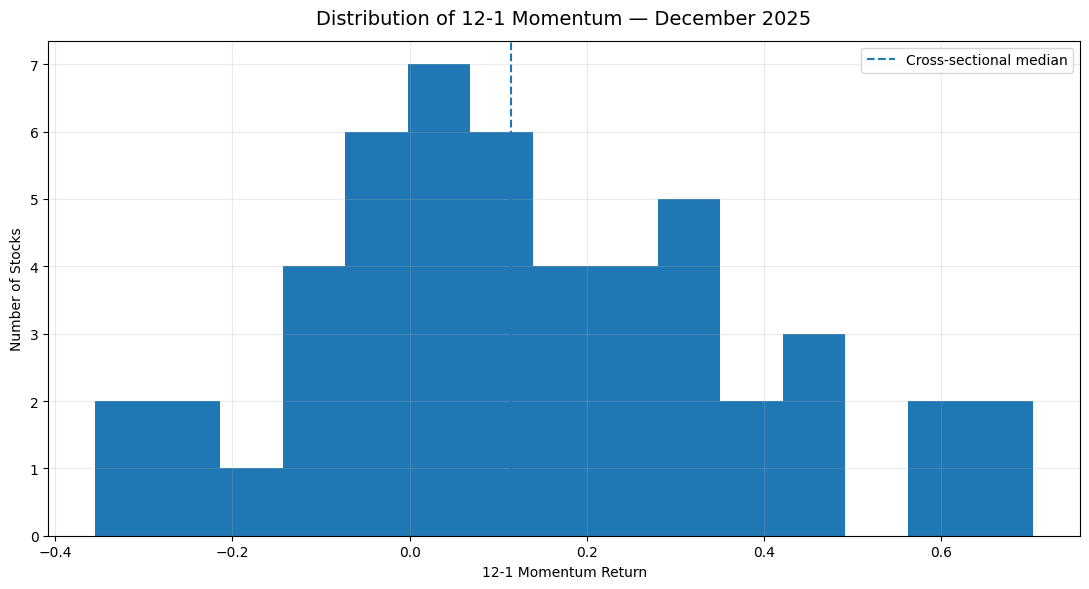

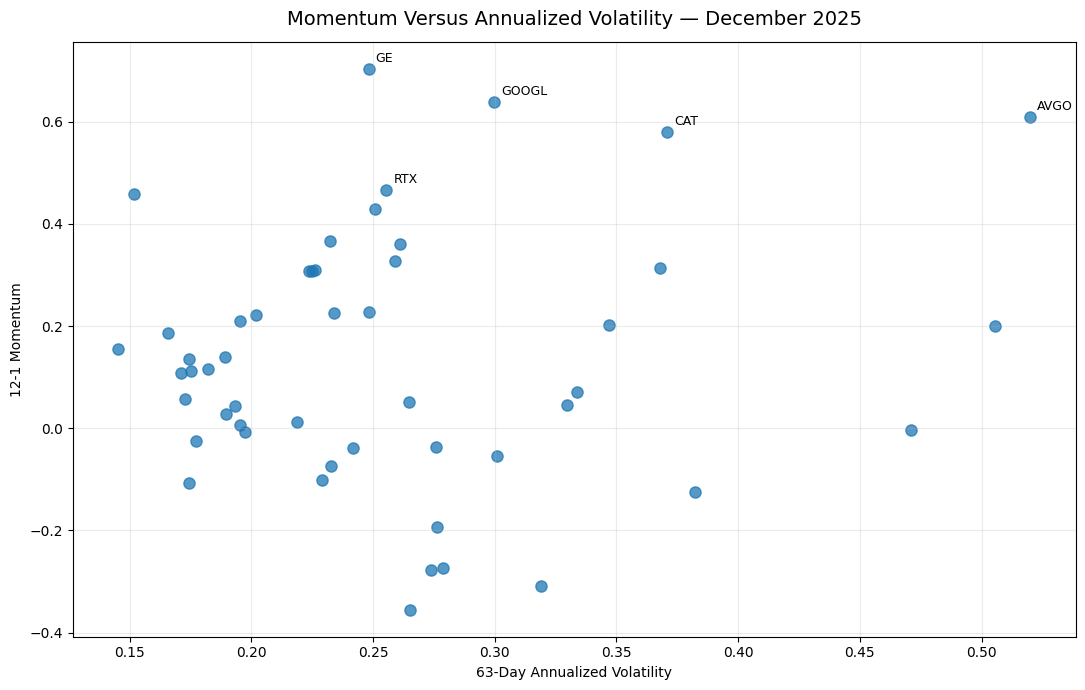

In [13]:
# ============================================================
# CELL 15: RAW FACTOR DIAGNOSTIC CHARTS
# ============================================================

# Momentum distribution
plt.figure(figsize=(11, 6))

plt.hist(
    factor_snapshot["12-1 Momentum"],
    bins=15,
)

plt.axvline(
    factor_snapshot["12-1 Momentum"].median(),
    linestyle="--",
    linewidth=1.5,
    label="Cross-sectional median",
)

plt.title(
    f"Distribution of 12-1 Momentum — "
    f"{LATEST_FACTOR_DATE.strftime('%B %Y')}",
    fontsize=14,
    pad=12,
)

plt.xlabel("12-1 Momentum Return")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()


# Momentum-versus-volatility scatterplot
plt.figure(figsize=(11, 7))

plt.scatter(
    factor_snapshot["Annualized Volatility"],
    factor_snapshot["12-1 Momentum"],
    s=65,
    alpha=0.75,
)

# Label the five strongest momentum stocks.
strongest_momentum_tickers = (
    factor_snapshot.nlargest(
        5,
        "12-1 Momentum",
    ).index
)

for ticker in strongest_momentum_tickers:
    plt.annotate(
        ticker,
        (
            factor_snapshot.loc[
                ticker,
                "Annualized Volatility",
            ],
            factor_snapshot.loc[
                ticker,
                "12-1 Momentum",
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.title(
    f"Momentum Versus Annualized Volatility — "
    f"{LATEST_FACTOR_DATE.strftime('%B %Y')}",
    fontsize=14,
    pad=12,
)

plt.xlabel("63-Day Annualized Volatility")
plt.ylabel("12-1 Momentum")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 5. Factor Standardization and Portfolio Selection

Raw factors use different units and numerical scales. Momentum is expressed as
a percentage return, while volatility is expressed as an annualized standard
deviation.

To make the factors comparable, this section performs three transformations:

1. **Winsorization:** Extreme observations are clipped at the 5th and 95th
   cross-sectional percentiles.
2. **Z-score standardization:** Each stock is measured relative to the
   cross-sectional mean and standard deviation for that month.
3. **Composite scoring:** Momentum and low volatility receive equal weights.

A higher composite score represents a more attractive stock under the current
two-factor model. The 15 highest-scoring stocks are selected at each monthly
rebalance date.

In [14]:
# ============================================================
# CELL 17: CROSS-SECTIONAL FACTOR TRANSFORMATIONS
# ============================================================

def winsorize_cross_section(
    values: pd.Series,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
) -> pd.Series:
    """
    Clip extreme observations within one cross-sectional factor snapshot.

    Winsorization reduces the influence of unusually large or small values
    without deleting the affected stocks.

    Parameters
    ----------
    values:
        One factor observation for each stock on a single date.
    lower_quantile:
        Lower clipping percentile.
    upper_quantile:
        Upper clipping percentile.

    Returns
    -------
    pd.Series
        Winsorized factor observations.
    """

    if not 0 <= lower_quantile < upper_quantile <= 1:
        raise ValueError(
            "Winsorization quantiles must satisfy "
            "0 <= lower < upper <= 1."
        )

    valid_values = values.dropna()

    if valid_values.empty:
        return values.copy()

    lower_bound = valid_values.quantile(lower_quantile)
    upper_bound = valid_values.quantile(upper_quantile)

    return values.clip(
        lower=lower_bound,
        upper=upper_bound,
    )


def zscore_cross_section(
    values: pd.Series,
) -> pd.Series:
    """
    Convert one cross-sectional factor snapshot into z-scores.

    Formula:

        z_i = (x_i - cross-sectional mean) /
              cross-sectional standard deviation

    Positive values are above the monthly universe average, while negative
    values are below the monthly universe average.
    """

    valid_values = values.dropna()

    if len(valid_values) < 2:
        return pd.Series(
            np.nan,
            index=values.index,
            dtype=float,
        )

    cross_sectional_mean = valid_values.mean()
    cross_sectional_std = valid_values.std(ddof=0)

    if np.isclose(cross_sectional_std, 0):
        return pd.Series(
            np.nan,
            index=values.index,
            dtype=float,
        )

    return (
        values - cross_sectional_mean
    ) / cross_sectional_std


def transform_factor_matrix(
    factor_data: pd.DataFrame,
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Winsorize and standardize a factor independently on every signal date.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Winsorized raw factor values and standardized z-scores.
    """

    winsorized_factor = factor_data.apply(
        winsorize_cross_section,
        axis=1,
        lower_quantile=lower_quantile,
        upper_quantile=upper_quantile,
    )

    standardized_factor = winsorized_factor.apply(
        zscore_cross_section,
        axis=1,
    )

    winsorized_factor.index.name = "Signal Date"
    standardized_factor.index.name = "Signal Date"

    return winsorized_factor, standardized_factor

In [15]:
# ============================================================
# CELL 18: STANDARDIZE AND COMBINE TECHNICAL FACTORS
# ============================================================

winsorized_momentum, momentum_zscore = transform_factor_matrix(
    factor_data=monthly_momentum,
    lower_quantile=0.05,
    upper_quantile=0.95,
)

winsorized_low_volatility, low_volatility_zscore = (
    transform_factor_matrix(
        factor_data=monthly_low_volatility_signal,
        lower_quantile=0.05,
        upper_quantile=0.95,
    )
)


# Equal factor weights for the first working strategy.
MOMENTUM_FACTOR_WEIGHT = 0.50
LOW_VOLATILITY_FACTOR_WEIGHT = 0.50

assert np.isclose(
    MOMENTUM_FACTOR_WEIGHT + LOW_VOLATILITY_FACTOR_WEIGHT,
    1.0,
), "Factor weights must sum to 1."


technical_composite_score = (
    MOMENTUM_FACTOR_WEIGHT * momentum_zscore
    + LOW_VOLATILITY_FACTOR_WEIGHT * low_volatility_zscore
)

technical_composite_score.index.name = "Signal Date"


# Require both factor observations for a stock to receive a composite score.
technical_composite_score = technical_composite_score.where(
    momentum_zscore.notna()
    & low_volatility_zscore.notna()
)


print("Technical composite factor created successfully.")
print(f"Composite score matrix: {technical_composite_score.shape}")

print()
print("Cross-sectional score diagnostics:")

composite_diagnostics = pd.DataFrame(
    {
        "Average Score": technical_composite_score.mean(axis=1),
        "Score Standard Deviation": technical_composite_score.std(
            axis=1,
            ddof=0,
        ),
        "Valid Stocks": technical_composite_score.notna().sum(axis=1),
    }
)

display(composite_diagnostics.describe())

Technical composite factor created successfully.
Composite score matrix: (120, 50)

Cross-sectional score diagnostics:


,Average Score,Score Standard Deviation,Valid Stocks
count,120.0000,120.0000,120.0000
mean,-0.0000,0.6611,50.0000
std,0.0000,0.1388,0.0000
min,-0.0000,0.3417,50.0000
25%,-0.0000,0.5396,50.0000
50%,0.0000,0.6676,50.0000
75%,0.0000,0.7634,50.0000
max,0.0000,0.9162,50.0000


In [16]:
# ============================================================
# CELL 19: MONTHLY PORTFOLIO SELECTION AND TARGET WEIGHTS
# ============================================================

def construct_equal_weight_portfolios(
    composite_scores: pd.DataFrame,
    number_of_holdings: int,
    maximum_position_weight: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Select the highest-scoring stocks and create equal target weights.

    Parameters
    ----------
    composite_scores:
        Monthly composite factor scores.
    number_of_holdings:
        Number of stocks selected each month.
    maximum_position_weight:
        Maximum permitted target allocation to one stock.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Monthly target weights and monthly cross-sectional ranks.
    """

    if number_of_holdings <= 0:
        raise ValueError(
            "The number of holdings must be positive."
        )

    equal_weight = 1.0 / number_of_holdings

    if equal_weight > maximum_position_weight:
        raise ValueError(
            "Equal weighting violates the configured maximum position size. "
            "Increase the number of holdings or the position-weight limit."
        )

    target_weights = pd.DataFrame(
        0.0,
        index=composite_scores.index,
        columns=composite_scores.columns,
    )

    score_ranks = composite_scores.rank(
        axis=1,
        ascending=False,
        method="first",
    )

    for signal_date in composite_scores.index:
        scores = composite_scores.loc[signal_date].dropna()

        if len(scores) < number_of_holdings:
            raise ValueError(
                f"Only {len(scores)} valid stocks were available on "
                f"{signal_date.date()}, but {number_of_holdings} are required."
            )

        selected_tickers = (
            scores
            .sort_values(ascending=False)
            .head(number_of_holdings)
            .index
        )

        target_weights.loc[
            signal_date,
            selected_tickers,
        ] = equal_weight

    target_weights.index.name = "Signal Date"
    score_ranks.index.name = "Signal Date"

    return target_weights, score_ranks


monthly_target_weights, monthly_factor_ranks = (
    construct_equal_weight_portfolios(
        composite_scores=technical_composite_score,
        number_of_holdings=CONFIG.number_of_holdings,
        maximum_position_weight=CONFIG.maximum_position_weight,
    )
)


# Portfolio validation.
weight_sums = monthly_target_weights.sum(axis=1)

number_selected = (
    monthly_target_weights
    .gt(0)
    .sum(axis=1)
)

maximum_observed_weight = (
    monthly_target_weights.max().max()
)


assert np.allclose(
    weight_sums,
    1.0,
), "At least one monthly portfolio does not sum to 100%."

assert (
    number_selected == CONFIG.number_of_holdings
).all(), "At least one portfolio has the wrong number of holdings."

assert (
    maximum_observed_weight
    <= CONFIG.maximum_position_weight + 1e-12
), "A portfolio weight exceeds the configured maximum."


print("Monthly portfolios constructed successfully.")
print(f"Portfolios created:       {len(monthly_target_weights)}")
print(f"Stocks per portfolio:     {CONFIG.number_of_holdings}")
print(f"Equal target weight:      {1 / CONFIG.number_of_holdings:.2%}")
print(f"Maximum observed weight:  {maximum_observed_weight:.2%}")
print(f"Minimum portfolio sum:    {weight_sums.min():.2%}")
print(f"Maximum portfolio sum:    {weight_sums.max():.2%}")

Monthly portfolios constructed successfully.
Portfolios created:       120
Stocks per portfolio:     15
Equal target weight:      6.67%
Maximum observed weight:  6.67%
Minimum portfolio sum:    100.00%
Maximum portfolio sum:    100.00%


In [17]:
# ============================================================
# CELL 20: LATEST PORTFOLIO HOLDINGS
# ============================================================

LATEST_PORTFOLIO_DATE = monthly_target_weights.index[-1]

latest_selected_tickers = (
    monthly_target_weights.loc[LATEST_PORTFOLIO_DATE]
    .loc[lambda weights: weights > 0]
    .index
)


latest_portfolio = pd.DataFrame(
    {
        "Composite Score": technical_composite_score.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Composite Rank": monthly_factor_ranks.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Momentum": monthly_momentum.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Momentum Z-Score": momentum_zscore.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Annualized Volatility": monthly_volatility.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Low-Volatility Z-Score": low_volatility_zscore.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
        "Target Weight": monthly_target_weights.loc[
            LATEST_PORTFOLIO_DATE,
            latest_selected_tickers,
        ],
    }
)

latest_portfolio = latest_portfolio.sort_values(
    "Composite Rank"
)

latest_portfolio.index.name = "Ticker"


print(
    f"Selected portfolio for signal date "
    f"{LATEST_PORTFOLIO_DATE.strftime('%Y-%m-%d')}"
)

display(latest_portfolio)

Selected portfolio for signal date 2025-12-31


,Composite Score,Composite Rank,Momentum,Momentum Z-Score,Annualized Volatility,Low-Volatility Z-Score,Target Weight
Ticker,,,,,,,
JNJ,1.2839,1.0000,0.4590,1.4018,0.1518,1.1659,0.0667
GE,1.0301,2.0000,0.7037,1.9924,0.2482,0.0678,0.0667
RTX,0.7014,3.0000,0.4665,1.4342,0.2555,-0.0314,0.0667
KO,0.6950,4.0000,0.1861,0.2240,0.1659,1.1659,0.0667
GOOGL,0.6759,5.0000,0.6389,1.9924,0.2998,-0.6407,0.0667
GS,0.6518,6.0000,0.4289,1.2722,0.2509,0.0315,0.0667
MS,0.6433,7.0000,0.3663,1.0016,0.2324,0.2850,0.0667
DUK,0.6275,8.0000,0.1549,0.0891,0.1454,1.1659,0.0667
CSCO,0.5784,9.0000,0.3085,0.7524,0.2237,0.4045,0.0667


### Latest Portfolio Selection

The chart below displays the composite scores of the stocks selected for the
latest portfolio.

Higher bars represent stocks with a stronger combination of medium-term
momentum and relatively low historical volatility.

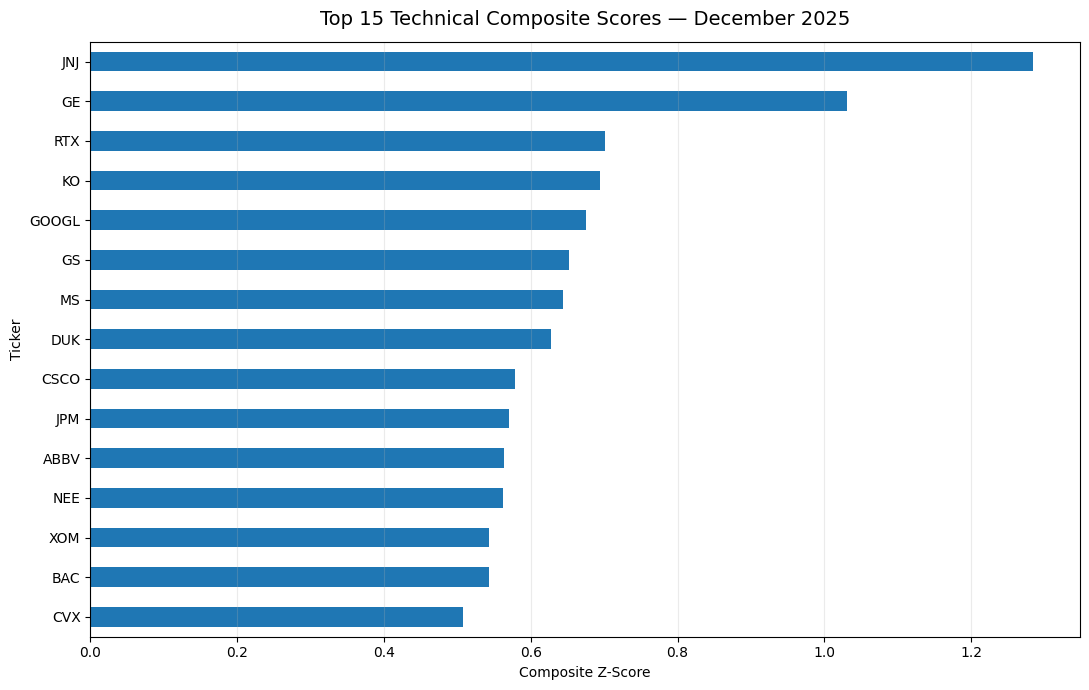

In [18]:
# ============================================================
# CELL 21: LATEST PORTFOLIO COMPOSITE-SCORE CHART
# ============================================================

latest_scores_for_chart = (
    latest_portfolio["Composite Score"]
    .sort_values(ascending=True)
)

ax = latest_scores_for_chart.plot(
    kind="barh",
    figsize=(11, 7),
)

ax.set_title(
    f"Top {CONFIG.number_of_holdings} Technical Composite Scores — "
    f"{LATEST_PORTFOLIO_DATE.strftime('%B %Y')}",
    fontsize=14,
    pad=12,
)

ax.set_xlabel("Composite Z-Score")
ax.set_ylabel("Ticker")
ax.grid(True, axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Portfolio Backtesting Engine

The backtest follows a conservative daily timing convention:

1. Factor signals are calculated using prices available at the month-end close.
2. The portfolio is rebalanced at the close of the following trading day.
3. New holdings begin earning returns on the next close-to-close interval.
4. Portfolio weights drift naturally as individual stocks rise or fall.
5. Transaction costs are deducted whenever the portfolio is rebalanced.

This approach prevents the strategy from earning returns before its investment
signal could realistically have been observed and traded.

### Transaction costs

Transaction costs are calculated as:

\[
\text{Cost Fraction}
=
\text{Gross Traded Notional}
\times
\frac{\text{Transaction Cost in Basis Points}}{10{,}000}
\]

Gross traded notional includes both purchases and sales. For example, replacing
one entire portfolio with another can produce traded notional approaching 200%
of portfolio value because the old positions must be sold and the new positions
must be purchased.

In [19]:
# ============================================================
# CELL 23: MAP MONTH-END SIGNALS TO EXECUTION DATES
# ============================================================

# Remove signals that cannot be executed inside the available dataset.
valid_execution_schedule = (
    REBALANCE_SCHEDULE
    .dropna(subset=["Execution Date"])
    .copy()
)

valid_execution_schedule = valid_execution_schedule[
    valid_execution_schedule["Execution Date"]
    <= pd.Timestamp(CONFIG.backtest_end)
].copy()


if valid_execution_schedule.empty:
    raise ValueError(
        "No executable portfolio signals were found."
    )


# Retrieve the portfolio selected on each corresponding signal date.
executed_target_weights = monthly_target_weights.loc[
    valid_execution_schedule["Signal Date"].tolist()
].copy()


# Change the index from signal dates to actual execution dates.
executed_target_weights.index = pd.DatetimeIndex(
    valid_execution_schedule["Execution Date"].to_numpy(),
    name="Execution Date",
)


# Keep the schedule itself indexed by execution date for auditing.
EXECUTION_SCHEDULE = (
    valid_execution_schedule
    .set_index("Execution Date")
    .sort_index()
)


assert executed_target_weights.index.is_unique, (
    "Execution dates must be unique."
)

assert executed_target_weights.index.is_monotonic_increasing, (
    "Execution dates must be sorted chronologically."
)

assert np.allclose(
    executed_target_weights.sum(axis=1),
    1.0,
), "Every executed target portfolio must sum to 100%."


print("Signal-to-execution mapping completed successfully.")
print(f"Executable rebalances: {len(EXECUTION_SCHEDULE)}")
print(
    f"First execution date: "
    f"{EXECUTION_SCHEDULE.index.min().date()}"
)
print(
    f"Final execution date: "
    f"{EXECUTION_SCHEDULE.index.max().date()}"
)

print()
display(EXECUTION_SCHEDULE.head())

Signal-to-execution mapping completed successfully.
Executable rebalances: 119
First execution date: 2016-02-01
Final execution date: 2025-12-01



,Signal Date,Signal Month
Execution Date,,
2016-02-01,2016-01-29,2016-01
2016-03-01,2016-02-29,2016-02
2016-04-01,2016-03-31,2016-03
2016-05-02,2016-04-29,2016-04
2016-06-01,2016-05-31,2016-05


In [20]:
# ============================================================
# CELL 24: DRIFTED-WEIGHT PORTFOLIO BACKTESTER
# ============================================================

def run_drifted_weight_backtest(
    asset_returns: pd.DataFrame,
    target_weights: pd.DataFrame,
    benchmark_returns: pd.Series,
    initial_capital: float,
    transaction_cost_bps: float,
    end_date: str,
) -> dict[str, object]:
    """
    Run a daily portfolio backtest with monthly rebalancing.

    Portfolio weights are reset to their targets on execution dates.
    Between rebalances, weights drift according to each stock's return.

    Daily timing:
    1. Existing holdings earn the current day's return.
    2. Portfolio weights drift based on individual performance.
    3. On an execution date, the portfolio rebalances at the close.
    4. Transaction costs are deducted.
    5. New weights begin earning returns on the following trading day.
    """

    if initial_capital <= 0:
        raise ValueError("Initial capital must be positive.")

    if transaction_cost_bps < 0:
        raise ValueError("Transaction costs cannot be negative.")

    if target_weights.empty:
        raise ValueError("Target-weight data cannot be empty.")

    missing_columns = [
        ticker
        for ticker in target_weights.columns
        if ticker not in asset_returns.columns
    ]

    if missing_columns:
        raise ValueError(
            "Target weights contain tickers missing from returns: "
            + ", ".join(missing_columns)
        )

    target_weights = (
        target_weights
        .sort_index()
        .reindex(columns=asset_returns.columns)
        .fillna(0.0)
    )

    if not np.allclose(target_weights.sum(axis=1), 1.0):
        raise ValueError(
            "Every target portfolio must sum to 100%."
        )

    first_execution_date = target_weights.index.min()
    final_simulation_date = pd.Timestamp(end_date)

    simulation_dates = asset_returns.index[
        (asset_returns.index >= first_execution_date)
        & (asset_returns.index <= final_simulation_date)
    ]

    if simulation_dates.empty:
        raise ValueError(
            "No daily return observations fall within the backtest period."
        )

    aligned_asset_returns = asset_returns.reindex(simulation_dates)

    aligned_benchmark_returns = benchmark_returns.reindex(
        simulation_dates
    )

    if aligned_benchmark_returns.iloc[1:].isna().any():
        missing_dates = aligned_benchmark_returns.index[
            aligned_benchmark_returns.isna()
        ]

        raise ValueError(
            "Benchmark returns are missing. "
            f"First missing date: {missing_dates[0]}"
        )

    transaction_cost_rate = transaction_cost_bps / 10_000.0

    # The strategy starts entirely in cash.
    current_weights = pd.Series(
        0.0,
        index=aligned_asset_returns.columns,
        dtype=float,
    )

    strategy_nav = float(initial_capital)

    daily_records = []
    weight_records = []
    rebalance_records = []

    target_weight_lookup = {
        execution_date: row.copy()
        for execution_date, row in target_weights.iterrows()
    }

    for current_date in simulation_dates:
        returns_today = aligned_asset_returns.loc[
            current_date
        ].copy()

        held_positions = current_weights.abs() > 1e-12

        missing_held_returns = returns_today[
            held_positions & returns_today.isna()
        ]

        if not missing_held_returns.empty:
            raise ValueError(
                f"Missing returns for held positions on "
                f"{current_date.date()}: "
                + ", ".join(missing_held_returns.index)
            )

        # Missing returns for stocks not currently held have no effect.
        returns_today = returns_today.fillna(0.0)

        nav_before_market = strategy_nav

        gross_portfolio_return = float(
            np.dot(
                current_weights.to_numpy(),
                returns_today.to_numpy(),
            )
        )

        nav_after_market = (
            nav_before_market
            * (1.0 + gross_portfolio_return)
        )

        if nav_after_market <= 0:
            raise RuntimeError(
                f"Portfolio value became non-positive on "
                f"{current_date.date()}."
            )

        # Allow weights to drift with stock performance.
        drifted_weights = (
            current_weights
            * (1.0 + returns_today)
            / (1.0 + gross_portfolio_return)
        )

        current_weights = drifted_weights

        was_rebalanced = False
        gross_traded_notional = 0.0
        transaction_cost_fraction = 0.0

        if current_date in target_weight_lookup:
            was_rebalanced = True

            new_target_weights = target_weight_lookup[
                current_date
            ]

            # Purchases plus sales as a percentage of portfolio value.
            gross_traded_notional = float(
                (
                    new_target_weights
                    - current_weights
                )
                .abs()
                .sum()
            )

            transaction_cost_fraction = (
                gross_traded_notional
                * transaction_cost_rate
            )

            if transaction_cost_fraction >= 1:
                raise RuntimeError(
                    "Transaction costs consumed the entire portfolio."
                )

            nav_after_costs = (
                nav_after_market
                * (1.0 - transaction_cost_fraction)
            )

            current_weights = new_target_weights.copy()

            rebalance_records.append(
                {
                    "Execution Date": current_date,
                    "Gross Traded Notional": gross_traded_notional,
                    "One-Way Turnover": gross_traded_notional / 2.0,
                    "Transaction Cost Fraction": (
                        transaction_cost_fraction
                    ),
                    "Transaction Cost Dollars": (
                        nav_after_market
                        * transaction_cost_fraction
                    ),
                    "Portfolio NAV After Costs": nav_after_costs,
                    "Number of Holdings": int(
                        (current_weights > 0).sum()
                    ),
                }
            )

        else:
            nav_after_costs = nav_after_market

        net_portfolio_return = (
            nav_after_costs
            / nav_before_market
            - 1.0
        )

        strategy_nav = nav_after_costs

        daily_records.append(
            {
                "Date": current_date,
                "Gross Return": gross_portfolio_return,
                "Net Return": net_portfolio_return,
                "Gross Traded Notional": gross_traded_notional,
                "Transaction Cost Fraction": (
                    transaction_cost_fraction
                ),
                "Rebalanced": was_rebalanced,
                "Strategy NAV": strategy_nav,
            }
        )

        weight_records.append(
            current_weights.to_numpy(copy=True)
        )

    daily_results = (
        pd.DataFrame(daily_records)
        .set_index("Date")
    )

    end_of_day_weights = pd.DataFrame(
        weight_records,
        index=simulation_dates,
        columns=aligned_asset_returns.columns,
    )

    end_of_day_weights.index.name = "Date"

    rebalance_log = pd.DataFrame(rebalance_records)

    if not rebalance_log.empty:
        rebalance_log = rebalance_log.set_index(
            "Execution Date"
        )

    # Benchmark starts at the same time as the strategy.
    benchmark_return_series = (
        aligned_benchmark_returns
        .fillna(0.0)
        .copy()
    )

    benchmark_return_series.iloc[0] = 0.0

    benchmark_nav = (
        initial_capital
        * (1.0 + benchmark_return_series).cumprod()
    )

    gross_strategy_nav = (
        initial_capital
        * (1.0 + daily_results["Gross Return"]).cumprod()
    )

    daily_results["Gross Strategy NAV"] = gross_strategy_nav
    daily_results["Benchmark Return"] = benchmark_return_series
    daily_results["Benchmark NAV"] = benchmark_nav

    daily_results["Active Return"] = (
        daily_results["Net Return"]
        - daily_results["Benchmark Return"]
    )

    return {
        "daily_results": daily_results,
        "end_of_day_weights": end_of_day_weights,
        "rebalance_log": rebalance_log,
    }


print("Backtesting function loaded successfully.")

Backtesting function loaded successfully.


In [21]:
# ============================================================
# CELL 25: RUN THE TECHNICAL MULTI-FACTOR BACKTEST
# ============================================================

BACKTEST_OUTPUT = run_drifted_weight_backtest(
    asset_returns=stock_returns,
    target_weights=executed_target_weights,
    benchmark_returns=benchmark_returns,
    initial_capital=CONFIG.initial_capital,
    transaction_cost_bps=CONFIG.transaction_cost_bps,
    end_date=CONFIG.backtest_end,
)


backtest_results = BACKTEST_OUTPUT["daily_results"]

daily_portfolio_weights = BACKTEST_OUTPUT[
    "end_of_day_weights"
]

rebalance_log = BACKTEST_OUTPUT[
    "rebalance_log"
]


print("Backtest completed successfully.")
print(
    f"Simulation start: "
    f"{backtest_results.index.min().date()}"
)
print(
    f"Simulation end:   "
    f"{backtest_results.index.max().date()}"
)
print(
    f"Trading dates:    "
    f"{len(backtest_results):,}"
)
print(
    f"Rebalances:       "
    f"{int(backtest_results['Rebalanced'].sum())}"
)

print()
print(
    f"Final net strategy value: "
    f"${backtest_results['Strategy NAV'].iloc[-1]:,.2f}"
)

print(
    f"Final gross strategy value: "
    f"${backtest_results['Gross Strategy NAV'].iloc[-1]:,.2f}"
)

print(
    f"Final benchmark value: "
    f"${backtest_results['Benchmark NAV'].iloc[-1]:,.2f}"
)

Backtest completed successfully.
Simulation start: 2016-02-01
Simulation end:   2025-12-31
Trading dates:    2,495
Rebalances:       119

Final net strategy value: $443,735.66
Final gross strategy value: $470,816.57
Final benchmark value: $415,486.15


In [22]:
# ============================================================
# CELL 26: BACKTEST VALIDATION AND REBALANCE REPORT
# ============================================================

assert not backtest_results.empty, (
    "The backtest produced no daily results."
)

assert backtest_results.index.is_monotonic_increasing, (
    "Backtest dates are not sorted."
)

assert backtest_results.index.is_unique, (
    "Duplicate dates were found."
)

assert (
    backtest_results[
        [
            "Gross Return",
            "Net Return",
            "Strategy NAV",
            "Benchmark NAV",
        ]
    ]
    .notna()
    .all()
    .all()
), "Missing values were found in required backtest outputs."

assert (
    backtest_results["Strategy NAV"] > 0
).all(), "Strategy NAV must remain positive."

assert (
    backtest_results["Benchmark NAV"] > 0
).all(), "Benchmark NAV must remain positive."


rebalance_weight_sums = daily_portfolio_weights.loc[
    executed_target_weights.index
].sum(axis=1)

assert np.allclose(
    rebalance_weight_sums,
    1.0,
), "Post-rebalance stock weights do not sum to 100%."


print("All core backtest validation checks passed.")

print()
print("Rebalance and transaction-cost summary:")

display(
    rebalance_log[
        [
            "Gross Traded Notional",
            "One-Way Turnover",
            "Transaction Cost Dollars",
            "Number of Holdings",
        ]
    ].describe()
)

total_transaction_costs = (
    rebalance_log["Transaction Cost Dollars"].sum()
)

average_one_way_turnover = (
    rebalance_log["One-Way Turnover"].mean()
)

print()
print(
    f"Total estimated transaction costs: "
    f"${total_transaction_costs:,.2f}"
)

print(
    f"Average one-way monthly turnover: "
    f"{average_one_way_turnover:.2%}"
)


All core backtest validation checks passed.

Rebalance and transaction-cost summary:


,Gross Traded Notional,One-Way Turnover,Transaction Cost Dollars,Number of Holdings
count,119.0000,119.0000,119.0000,119.0000
mean,0.4977,0.2488,107.1726,15.0000
std,0.2232,0.1116,59.8702,0.0000
min,0.0332,0.0166,5.7865,15.0000
25%,0.2978,0.1489,59.8259,15.0000
50%,0.4508,0.2254,95.1259,15.0000
75%,0.6774,0.3387,139.5925,15.0000
max,1.1031,0.5515,317.7726,15.0000



Total estimated transaction costs: $12,753.54
Average one-way monthly turnover: 24.88%


### Strategy Growth Versus Benchmark

The chart compares the growth of the technical multi-factor portfolio with a
passive investment in SPY.

The net strategy line includes estimated transaction costs. The gross strategy
line shows performance before those costs.


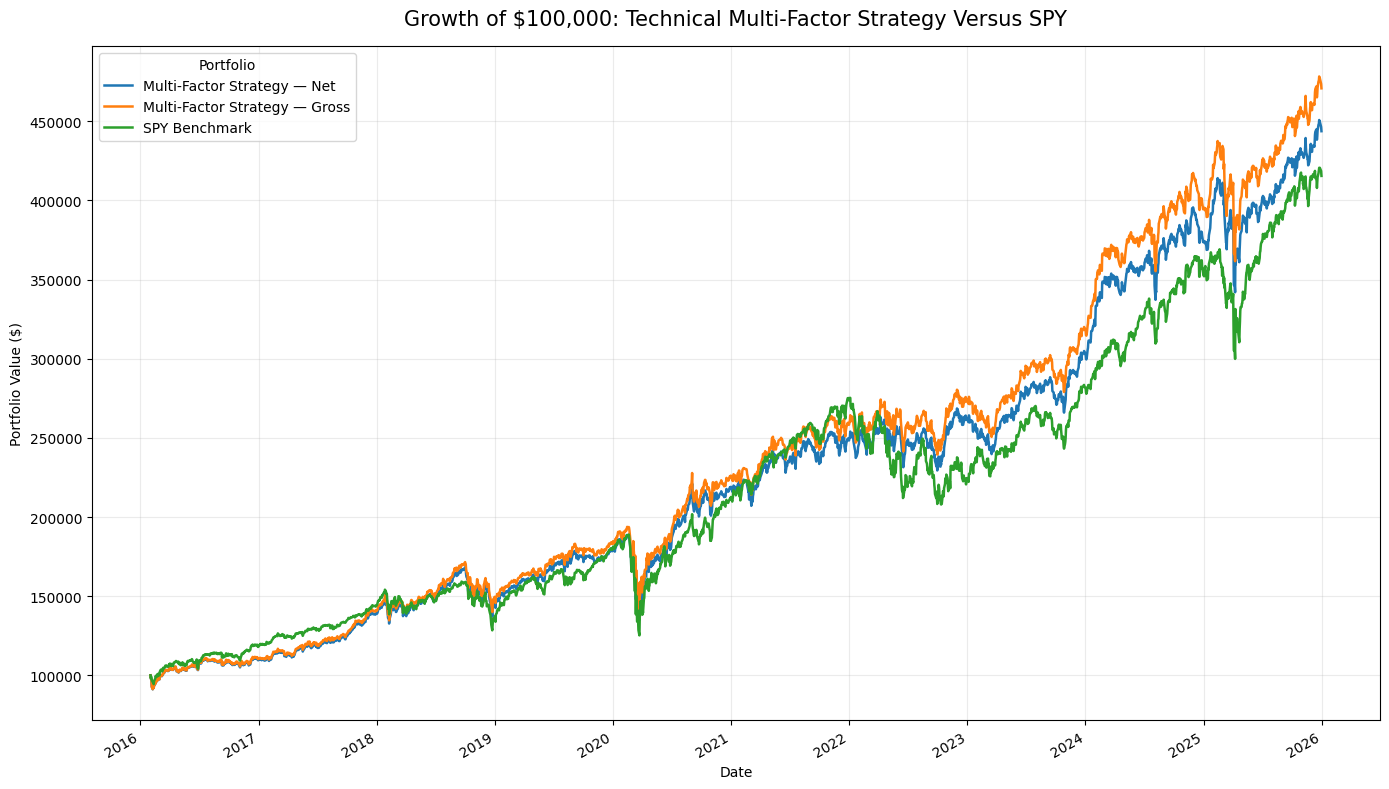

In [23]:
# ============================================================
# CELL 27: STRATEGY AND BENCHMARK EQUITY CURVES
# ============================================================

equity_curves = backtest_results[
    [
        "Strategy NAV",
        "Gross Strategy NAV",
        "Benchmark NAV",
    ]
].copy()

equity_curves.columns = [
    "Multi-Factor Strategy — Net",
    "Multi-Factor Strategy — Gross",
    "SPY Benchmark",
]


ax = equity_curves.plot(
    figsize=(14, 8),
    linewidth=1.8,
)

ax.set_title(
    "Growth of $100,000: Technical Multi-Factor Strategy Versus SPY",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(True, alpha=0.25)
ax.legend(title="Portfolio")

plt.tight_layout()
plt.show()


## 7. Performance and Risk Analytics

This section evaluates the strategy using institutional portfolio metrics rather
than relying only on its ending value.

The analysis includes:

- Total return and compound annual growth rate
- Annualized volatility
- Sharpe and Sortino ratios
- Maximum drawdown and Calmar ratio
- Alpha and beta relative to SPY
- Tracking error and information ratio
- Historical Value at Risk and Expected Shortfall
- Monthly win rate
- Rolling volatility and rolling Sharpe ratio

A three-month U.S. Treasury yield from FRED is used as the approximate
risk-free rate.

In [24]:
# ============================================================
# CELL 29: DOWNLOAD AND ALIGN THE RISK-FREE RATE
# ============================================================

def download_daily_risk_free_rate(
    start_date: str,
    end_date: str,
    trading_dates: pd.DatetimeIndex,
    annualization_factor: int = 252,
) -> pd.Series:
    """
    Download the 3-month Treasury yield from FRED and convert it into
    an approximate daily risk-free return.

    FRED series DGS3MO is reported as an annual percentage yield.

    Returns
    -------
    pd.Series
        Daily risk-free returns aligned to the backtest's trading dates.
    """

    try:
        treasury_data = pdr.DataReader(
            "DGS3MO",
            "fred",
            start_date,
            end_date,
        )

        annual_yield = (
            treasury_data["DGS3MO"]
            .div(100.0)
            .reindex(trading_dates)
            .ffill()
            .bfill()
        )

        daily_risk_free_rate = (
            (1.0 + annual_yield)
            ** (1.0 / annualization_factor)
            - 1.0
        )

        daily_risk_free_rate.name = "Daily Risk-Free Return"

        print("FRED risk-free-rate data loaded successfully.")

        return daily_risk_free_rate

    except Exception as error:
        print(
            "WARNING: FRED data could not be downloaded. "
            "A zero risk-free rate will be used."
        )
        print(f"Reason: {type(error).__name__}: {error}")

        return pd.Series(
            0.0,
            index=trading_dates,
            name="Daily Risk-Free Return",
        )


daily_risk_free_rate = download_daily_risk_free_rate(
    start_date=backtest_results.index.min().strftime("%Y-%m-%d"),
    end_date=backtest_results.index.max().strftime("%Y-%m-%d"),
    trading_dates=backtest_results.index,
    annualization_factor=CONFIG.annualization_factor,
)


print()
print("Risk-free-rate summary:")

display(
    pd.DataFrame(
        {
            "Annualized Approximation": (
                (1.0 + daily_risk_free_rate)
                ** CONFIG.annualization_factor
                - 1.0
            )
        }
    ).describe()
)

FRED risk-free-rate data loaded successfully.

Risk-free-rate summary:


,Annualized Approximation
count,"2,495.0000"
mean,0.0226
std,0.0197
min,0.0000
25%,0.0032
50%,0.0180
75%,0.0434
max,0.0563


In [25]:
# ============================================================
# CELL 30: PERFORMANCE AND RISK METRIC FUNCTIONS
# ============================================================

def calculate_drawdown(
    nav_series: pd.Series,
) -> pd.Series:
    """
    Calculate the percentage decline from the previous portfolio peak.
    """

    running_peak = nav_series.cummax()

    drawdown = (
        nav_series / running_peak - 1.0
    )

    drawdown.name = "Drawdown"

    return drawdown


def safe_divide(
    numerator: float,
    denominator: float,
) -> float:
    """Return NaN when division is undefined."""

    if denominator is None:
        return np.nan

    if not np.isfinite(denominator):
        return np.nan

    if np.isclose(denominator, 0.0):
        return np.nan

    return numerator / denominator


def calculate_performance_metrics(
    returns: pd.Series,
    nav: pd.Series,
    risk_free_returns: pd.Series,
    annualization_factor: int = 252,
    benchmark_returns: pd.Series | None = None,
) -> pd.Series:
    """
    Calculate professional portfolio-performance statistics.
    """

    aligned_data = pd.concat(
        [
            returns.rename("Portfolio"),
            risk_free_returns.rename("Risk Free"),
        ],
        axis=1,
    ).dropna()

    portfolio_returns = aligned_data["Portfolio"]
    risk_free = aligned_data["Risk Free"]

    if portfolio_returns.empty:
        raise ValueError(
            "No valid portfolio returns were available."
        )

    elapsed_years = (
        (
            nav.index[-1]
            - nav.index[0]
        ).days
        / 365.25
    )

    total_return = (
        nav.iloc[-1]
        / nav.iloc[0]
        - 1.0
    )

    cagr = (
        nav.iloc[-1]
        / nav.iloc[0]
    ) ** (1.0 / elapsed_years) - 1.0

    annualized_return = (
        portfolio_returns.mean()
        * annualization_factor
    )

    annualized_volatility = (
        portfolio_returns.std(ddof=1)
        * np.sqrt(annualization_factor)
    )

    excess_returns = (
        portfolio_returns - risk_free
    )

    sharpe_ratio = safe_divide(
        excess_returns.mean()
        * annualization_factor,
        excess_returns.std(ddof=1)
        * np.sqrt(annualization_factor),
    )

    downside_returns = excess_returns[
        excess_returns < 0
    ]

    downside_deviation = (
        downside_returns.std(ddof=1)
        * np.sqrt(annualization_factor)
        if len(downside_returns) > 1
        else np.nan
    )

    sortino_ratio = safe_divide(
        excess_returns.mean()
        * annualization_factor,
        downside_deviation,
    )

    drawdown = calculate_drawdown(nav)

    maximum_drawdown = drawdown.min()

    calmar_ratio = safe_divide(
        cagr,
        abs(maximum_drawdown),
    )

    monthly_returns = (
        (1.0 + portfolio_returns)
        .resample("ME")
        .prod()
        - 1.0
    )

    monthly_win_rate = (
        monthly_returns.gt(0).mean()
    )

    historical_var_95 = (
        -portfolio_returns.quantile(0.05)
    )

    tail_losses = portfolio_returns[
        portfolio_returns
        <= portfolio_returns.quantile(0.05)
    ]

    expected_shortfall_95 = (
        -tail_losses.mean()
        if not tail_losses.empty
        else np.nan
    )

    alpha = np.nan
    beta = np.nan
    tracking_error = np.nan
    information_ratio = np.nan

    if benchmark_returns is not None:
        regression_data = pd.concat(
            [
                portfolio_returns.rename("Portfolio"),
                benchmark_returns.rename("Benchmark"),
                risk_free.rename("Risk Free"),
            ],
            axis=1,
        ).dropna()

        strategy_excess = (
            regression_data["Portfolio"]
            - regression_data["Risk Free"]
        )

        benchmark_excess = (
            regression_data["Benchmark"]
            - regression_data["Risk Free"]
        )

        benchmark_variance = benchmark_excess.var(
            ddof=1
        )

        beta = safe_divide(
            strategy_excess.cov(benchmark_excess),
            benchmark_variance,
        )

        if np.isfinite(beta):
            daily_alpha = (
                strategy_excess.mean()
                - beta * benchmark_excess.mean()
            )

            alpha = (
                daily_alpha
                * annualization_factor
            )

        active_returns = (
            regression_data["Portfolio"]
            - regression_data["Benchmark"]
        )

        tracking_error = (
            active_returns.std(ddof=1)
            * np.sqrt(annualization_factor)
        )

        information_ratio = safe_divide(
            active_returns.mean()
            * annualization_factor,
            tracking_error,
        )

    return pd.Series(
        {
            "Total Return": total_return,
            "CAGR": cagr,
            "Annualized Arithmetic Return": annualized_return,
            "Annualized Volatility": annualized_volatility,
            "Sharpe Ratio": sharpe_ratio,
            "Sortino Ratio": sortino_ratio,
            "Maximum Drawdown": maximum_drawdown,
            "Calmar Ratio": calmar_ratio,
            "Annualized Alpha": alpha,
            "Beta": beta,
            "Tracking Error": tracking_error,
            "Information Ratio": information_ratio,
            "Daily VaR 95%": historical_var_95,
            "Daily Expected Shortfall 95%": expected_shortfall_95,
            "Monthly Win Rate": monthly_win_rate,
            "Best Month": monthly_returns.max(),
            "Worst Month": monthly_returns.min(),
        }
    )

In [26]:
# ============================================================
# CELL 31: STRATEGY AND BENCHMARK PERFORMANCE TABLE
# ============================================================

strategy_metrics = calculate_performance_metrics(
    returns=backtest_results["Net Return"],
    nav=backtest_results["Strategy NAV"],
    risk_free_returns=daily_risk_free_rate,
    annualization_factor=CONFIG.annualization_factor,
    benchmark_returns=backtest_results["Benchmark Return"],
)


benchmark_metrics = calculate_performance_metrics(
    returns=backtest_results["Benchmark Return"],
    nav=backtest_results["Benchmark NAV"],
    risk_free_returns=daily_risk_free_rate,
    annualization_factor=CONFIG.annualization_factor,
    benchmark_returns=None,
)


performance_table = pd.concat(
    [
        strategy_metrics.rename("Multi-Factor Strategy"),
        benchmark_metrics.rename("SPY Benchmark"),
    ],
    axis=1,
)


PERCENTAGE_METRICS = [
    "Total Return",
    "CAGR",
    "Annualized Arithmetic Return",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Annualized Alpha",
    "Tracking Error",
    "Daily VaR 95%",
    "Daily Expected Shortfall 95%",
    "Monthly Win Rate",
    "Best Month",
    "Worst Month",
]


formatted_performance_table = (
    performance_table.copy()
)

for metric in PERCENTAGE_METRICS:
    formatted_performance_table.loc[metric] = (
        performance_table.loc[metric]
        .map(
            lambda value: (
                f"{value:.2%}"
                if pd.notna(value)
                else "N/A"
            )
        )
    )

for metric in performance_table.index:
    if metric not in PERCENTAGE_METRICS:
        formatted_performance_table.loc[metric] = (
            performance_table.loc[metric]
            .map(
                lambda value: (
                    f"{value:.3f}"
                    if pd.notna(value)
                    else "N/A"
                )
            )
        )


print("Performance and risk summary:")

display(formatted_performance_table)

Performance and risk summary:


,Multi-Factor Strategy,SPY Benchmark
Total Return,344.18%,315.49%
CAGR,16.23%,15.45%
Annualized Arithmetic Return,16.50%,16.01%
Annualized Volatility,16.99%,17.96%
Sharpe Ratio,0.841,0.768
Sortino Ratio,1.031,0.923
Maximum Drawdown,-28.46%,-33.72%
Calmar Ratio,0.570,0.458
Annualized Alpha,3.01%,N/A
Beta,0.817,N/A


### Drawdown Analysis

Drawdown measures the decline from each portfolio's previous all-time high.

A value of -20% means that the portfolio is currently 20% below its previous
peak. Maximum drawdown is often more intuitive to investors than volatility
because it measures realized loss severity.

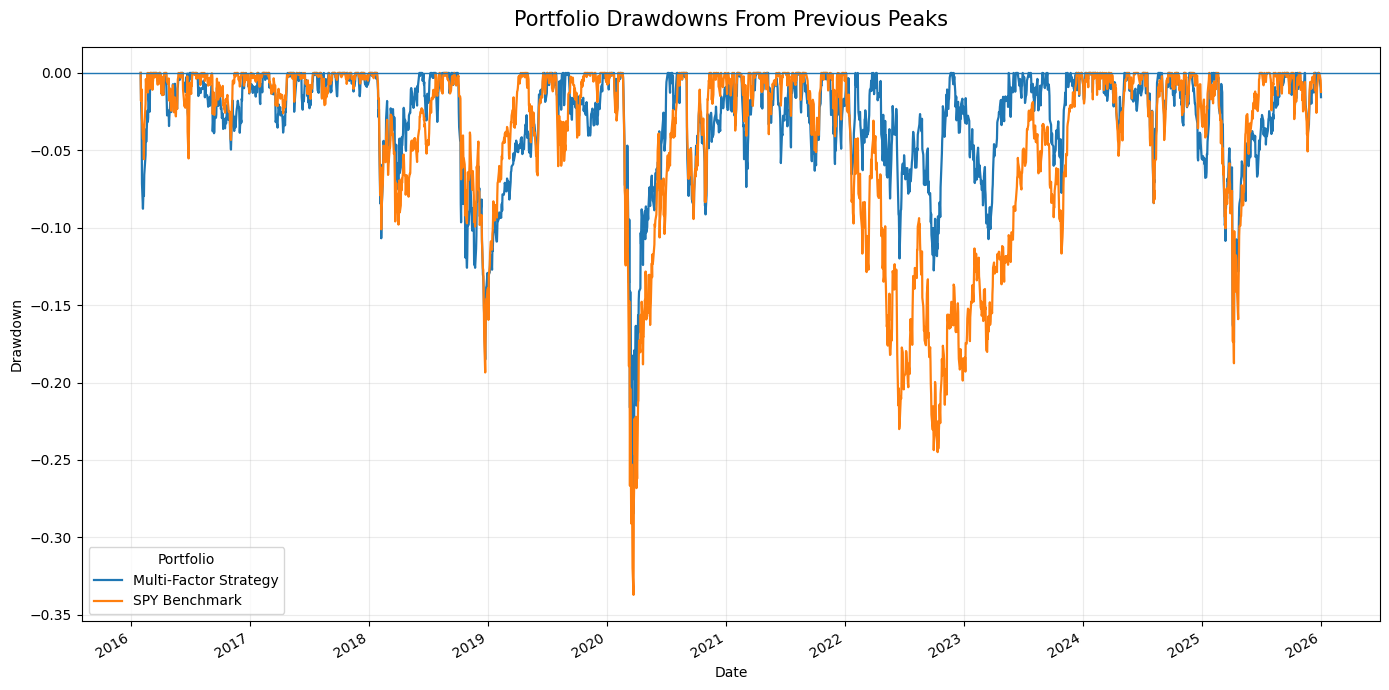

Strategy maximum drawdown: -28.46%
SPY maximum drawdown: -33.72%


In [27]:
# ============================================================
# CELL 32: UNDERWATER DRAWDOWN CHART
# ============================================================

strategy_drawdown = calculate_drawdown(
    backtest_results["Strategy NAV"]
)

benchmark_drawdown = calculate_drawdown(
    backtest_results["Benchmark NAV"]
)


drawdown_data = pd.concat(
    [
        strategy_drawdown.rename(
            "Multi-Factor Strategy"
        ),
        benchmark_drawdown.rename(
            "SPY Benchmark"
        ),
    ],
    axis=1,
)


ax = drawdown_data.plot(
    figsize=(14, 7),
    linewidth=1.6,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Portfolio Drawdowns From Previous Peaks",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25)
ax.legend(title="Portfolio")

plt.tight_layout()
plt.show()


print(
    "Strategy maximum drawdown: "
    f"{strategy_drawdown.min():.2%}"
)

print(
    "SPY maximum drawdown: "
    f"{benchmark_drawdown.min():.2%}"
)

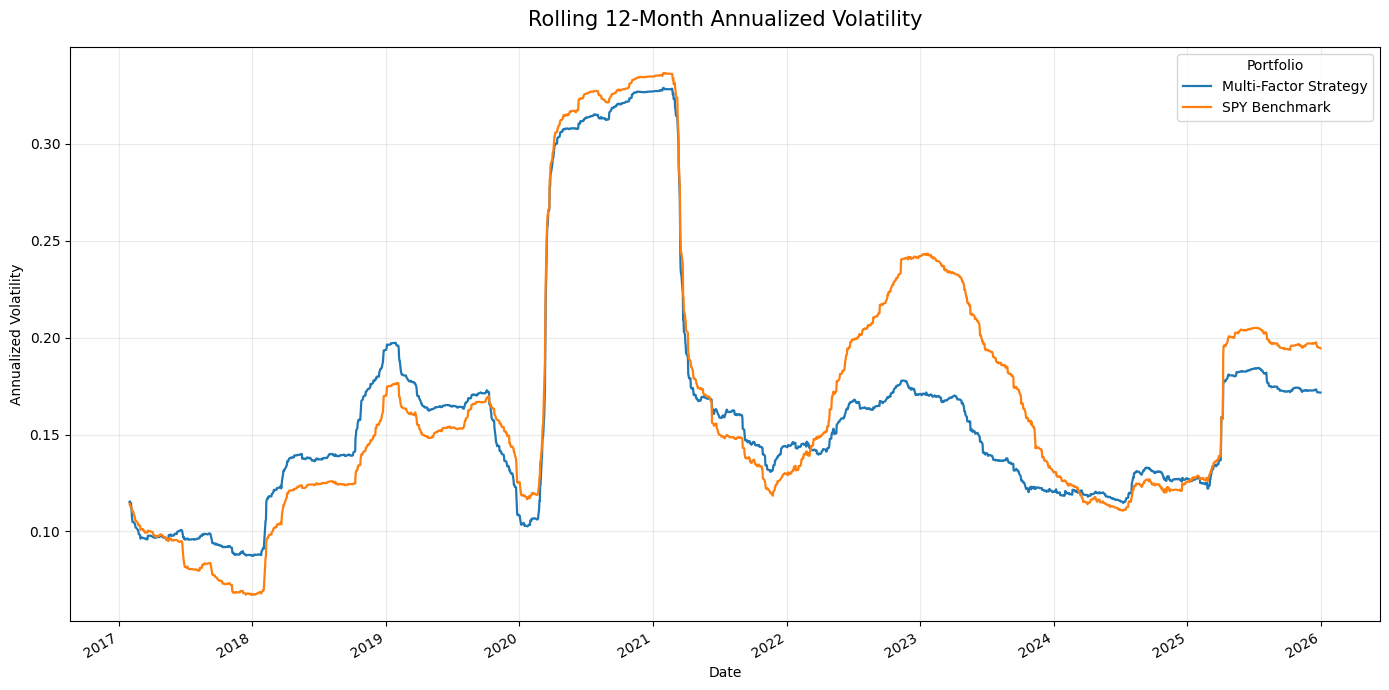

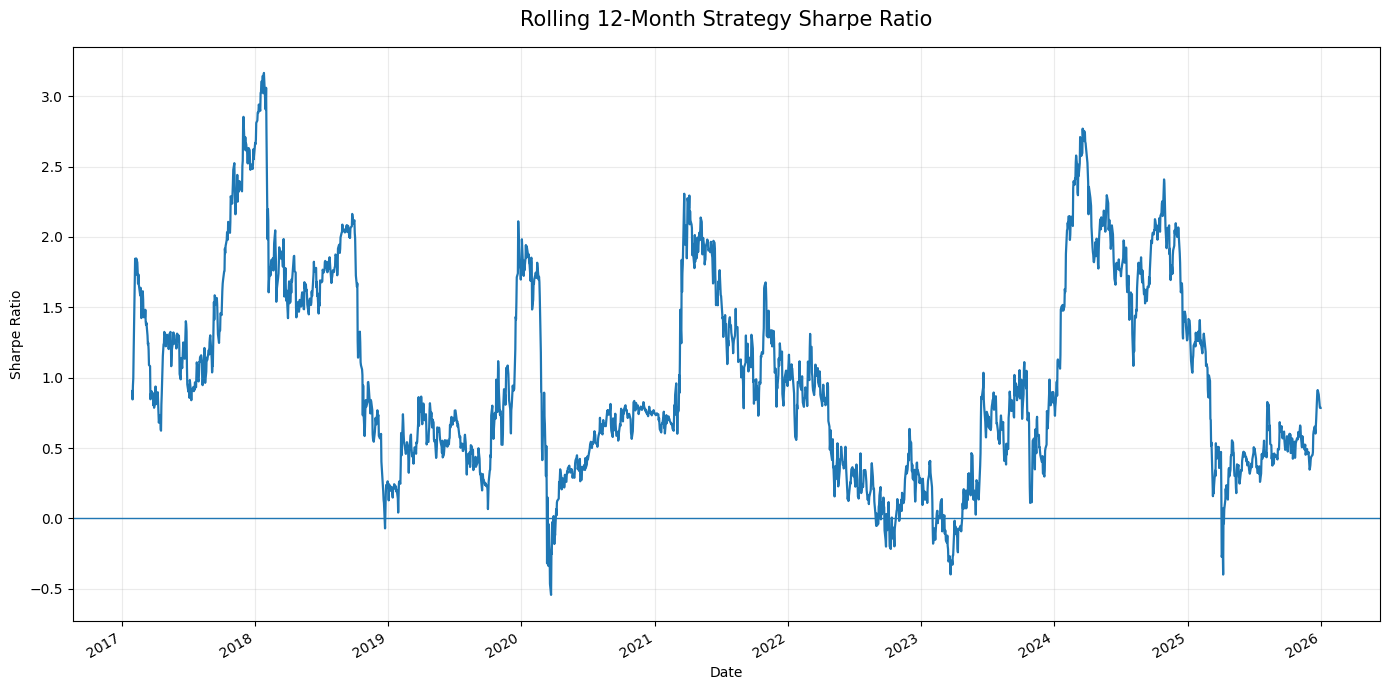

In [28]:
# ============================================================
# CELL 33: ROLLING VOLATILITY AND SHARPE RATIO
# ============================================================

ROLLING_WINDOW = 252


rolling_strategy_volatility = (
    backtest_results["Net Return"]
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .std(ddof=1)
    * np.sqrt(CONFIG.annualization_factor)
)


rolling_benchmark_volatility = (
    backtest_results["Benchmark Return"]
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .std(ddof=1)
    * np.sqrt(CONFIG.annualization_factor)
)


rolling_excess_returns = (
    backtest_results["Net Return"]
    - daily_risk_free_rate
)


rolling_sharpe_ratio = (
    rolling_excess_returns
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .mean()
    * CONFIG.annualization_factor
) / (
    rolling_excess_returns
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .std(ddof=1)
    * np.sqrt(CONFIG.annualization_factor)
)


rolling_volatility = pd.concat(
    [
        rolling_strategy_volatility.rename(
            "Multi-Factor Strategy"
        ),
        rolling_benchmark_volatility.rename(
            "SPY Benchmark"
        ),
    ],
    axis=1,
)


ax = rolling_volatility.plot(
    figsize=(14, 7),
    linewidth=1.6,
)

ax.set_title(
    "Rolling 12-Month Annualized Volatility",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.grid(True, alpha=0.25)
ax.legend(title="Portfolio")

plt.tight_layout()
plt.show()


ax = rolling_sharpe_ratio.plot(
    figsize=(14, 7),
    linewidth=1.6,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Rolling 12-Month Strategy Sharpe Ratio",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Sharpe Ratio")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## 8. Point-in-Time SEC Fundamental Data

This section retrieves standardized XBRL financial-statement facts from the
SEC EDGAR Company Facts API.

To reduce look-ahead bias, each monthly signal may use only facts whose SEC
filing date is on or before that signal date.

The first fundamental implementation uses annual 10-K data because annual
figures are easier to compare consistently across companies than cumulative
year-to-date quarterly figures.

The collected accounting variables include:

- Revenue
- Net income
- Operating income
- Operating cash flow
- Capital expenditures
- Gross profit
- Total assets
- Total liabilities
- Shareholders' equity
- Shares outstanding

These variables will later be transformed into value and quality factors.

In [29]:
# ============================================================
# CELL 35: SEC API CONFIGURATION, CACHING, AND REQUEST SESSION
# ============================================================

import json
import time
from pathlib import Path

import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


# ------------------------------------------------------------
# Private SEC contact configuration
#
# Recommended in Colab:
# 1. Open the key icon in the left sidebar.
# 2. Add SEC_CONTACT_NAME and SEC_CONTACT_EMAIL as secrets.
#
# The values are read at runtime and are not stored in this notebook.
# If secrets are unavailable, Colab prompts for them privately.
# ------------------------------------------------------------

import os
from getpass import getpass


def read_private_setting(
    setting_name: str,
    prompt_text: str,
) -> str:
    """Read a private setting from the environment, Colab Secrets, or input."""

    value = os.getenv(setting_name)

    if value:
        return value.strip()

    try:
        from google.colab import userdata

        value = userdata.get(setting_name)

        if value:
            return value.strip()

    except Exception:
        pass

    return getpass(prompt_text).strip()


SEC_CONTACT_NAME = read_private_setting(
    "SEC_CONTACT_NAME",
    "Enter the name used for the SEC request header: ",
)

SEC_CONTACT_EMAIL = read_private_setting(
    "SEC_CONTACT_EMAIL",
    "Enter the email used for the SEC request header: ",
)


if (
    not SEC_CONTACT_NAME
    or "@" not in SEC_CONTACT_EMAIL
):
    raise ValueError(
        "A valid SEC contact name and email are required."
    )


SEC_USER_AGENT = (
    f"{SEC_CONTACT_NAME} {SEC_CONTACT_EMAIL} "
    "Multi-Factor Equity Research Project"
)


# Store downloaded JSON locally so rerunning later cells does not
# repeatedly request identical files during the current Colab session.
SEC_CACHE_DIRECTORY = Path(
    "/content/sec_companyfacts_cache"
)

SEC_CACHE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# Automatically retry temporary server and rate-limit errors.
retry_policy = Retry(
    total=5,
    connect=5,
    read=5,
    backoff_factor=1.0,
    status_forcelist=[
        429,
        500,
        502,
        503,
        504,
    ],
    allowed_methods=frozenset(["GET"]),
)


SEC_SESSION = requests.Session()

SEC_SESSION.headers.update(
    {
        "User-Agent": SEC_USER_AGENT,
        "Accept-Encoding": "gzip, deflate",
        "Accept": "application/json",
    }
)

SEC_SESSION.mount(
    "https://",
    HTTPAdapter(max_retries=retry_policy),
)


def sec_get_json(
    url: str,
    cache_file: Path | None = None,
    pause_seconds: float = 0.15,
) -> dict:
    """
    Download JSON from an SEC endpoint with local caching.

    A short pause after each uncached request keeps the request frequency
    comfortably below the SEC's published fair-access threshold.

    Parameters
    ----------
    url:
        SEC JSON endpoint.
    cache_file:
        Optional local path used to save and reuse the response.
    pause_seconds:
        Delay following each network request.

    Returns
    -------
    dict
        Decoded JSON response.
    """

    if cache_file is not None and cache_file.exists():
        with cache_file.open(
            "r",
            encoding="utf-8",
        ) as file:
            return json.load(file)

    response = SEC_SESSION.get(
        url,
        timeout=60,
    )

    response.raise_for_status()

    payload = response.json()

    if cache_file is not None:
        with cache_file.open(
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(payload, file)

    time.sleep(pause_seconds)

    return payload


print("SEC request configuration loaded successfully.")
print("SEC user-agent configured from private runtime values.")
print(f"Cache directory: {SEC_CACHE_DIRECTORY}")

SEC request configuration loaded successfully.
SEC user-agent configured from private runtime values.
Cache directory: /content/sec_companyfacts_cache


In [30]:
# ============================================================
# CELL 36: MAP THE INVESTMENT UNIVERSE TO SEC CIK NUMBERS
# ============================================================

SEC_TICKER_MAPPING_URL = (
    "https://www.sec.gov/files/company_tickers.json"
)

ticker_mapping_payload = sec_get_json(
    url=SEC_TICKER_MAPPING_URL,
    cache_file=(
        SEC_CACHE_DIRECTORY
        / "company_tickers.json"
    ),
)


ticker_mapping = (
    pd.DataFrame.from_dict(
        ticker_mapping_payload,
        orient="index",
    )
    .rename(
        columns={
            "ticker": "Ticker",
            "title": "Company",
            "cik_str": "CIK",
        }
    )
)


ticker_mapping["Ticker"] = (
    ticker_mapping["Ticker"]
    .astype(str)
    .str.upper()
    .str.strip()
)

ticker_mapping["CIK"] = pd.to_numeric(
    ticker_mapping["CIK"],
    errors="coerce",
).astype("Int64")


ticker_mapping = (
    ticker_mapping
    .dropna(subset=["Ticker", "CIK"])
    .drop_duplicates(
        subset=["Ticker"],
        keep="first",
    )
    .set_index("Ticker")
    .sort_index()
)


missing_cik_tickers = [
    ticker
    for ticker in UNIVERSE
    if ticker not in ticker_mapping.index
]


if missing_cik_tickers:
    raise ValueError(
        "The following universe tickers could not be mapped to SEC CIKs: "
        + ", ".join(missing_cik_tickers)
    )


universe_sec_mapping = (
    ticker_mapping.loc[
        UNIVERSE,
        [
            "Company",
            "CIK",
        ],
    ]
    .copy()
)


print("All universe stocks were matched to SEC registrants.")
print(f"Mapped companies: {len(universe_sec_mapping)}")

display(universe_sec_mapping.head(10))

All universe stocks were matched to SEC registrants.
Mapped companies: 50


,Company,CIK
Ticker,,
AAPL,Apple Inc.,320193
MSFT,MICROSOFT CORP,789019
NVDA,NVIDIA CORP,1045810
AVGO,Broadcom Inc.,1730168
ORCL,ORACLE CORP,1341439
CRM,"Salesforce, Inc.",1108524
ADBE,ADOBE INC.,796343
CSCO,"CISCO SYSTEMS, INC.",858877
GOOGL,Alphabet Inc.,1652044


In [31]:
# ============================================================
# CELL 37: DOWNLOAD SEC COMPANY FACTS FOR ALL 50 STOCKS
# ============================================================

def download_sec_companyfacts(
    ticker: str,
    cik: int,
) -> dict:
    """
    Download the complete SEC Company Facts JSON file for one company.
    """

    padded_cik = f"{int(cik):010d}"

    endpoint = (
        "https://data.sec.gov/api/xbrl/companyfacts/"
        f"CIK{padded_cik}.json"
    )

    cache_file = (
        SEC_CACHE_DIRECTORY
        / f"{ticker}_CIK{padded_cik}_companyfacts.json"
    )

    return sec_get_json(
        url=endpoint,
        cache_file=cache_file,
    )


SEC_COMPANYFACTS: dict[str, dict] = {}


for position, ticker in enumerate(
    UNIVERSE,
    start=1,
):
    cik = int(
        universe_sec_mapping.loc[
            ticker,
            "CIK",
        ]
    )

    try:
        SEC_COMPANYFACTS[ticker] = (
            download_sec_companyfacts(
                ticker=ticker,
                cik=cik,
            )
        )

        print(
            f"[{position:02d}/{len(UNIVERSE)}] "
            f"Downloaded {ticker}"
        )

    except Exception as error:
        raise RuntimeError(
            f"SEC Company Facts download failed for {ticker}: "
            f"{type(error).__name__}: {error}"
        ) from error


assert len(SEC_COMPANYFACTS) == len(UNIVERSE), (
    "The Company Facts download is incomplete."
)


print()
print("SEC Company Facts download completed successfully.")
print(f"Companies downloaded: {len(SEC_COMPANYFACTS)}")

[01/50] Downloaded AAPL
[02/50] Downloaded MSFT
[03/50] Downloaded NVDA
[04/50] Downloaded AVGO
[05/50] Downloaded ORCL
[06/50] Downloaded CRM
[07/50] Downloaded ADBE
[08/50] Downloaded CSCO
[09/50] Downloaded GOOGL
[10/50] Downloaded META
[11/50] Downloaded NFLX
[12/50] Downloaded DIS
[13/50] Downloaded CMCSA
[14/50] Downloaded AMZN
[15/50] Downloaded TSLA
[16/50] Downloaded HD
[17/50] Downloaded MCD
[18/50] Downloaded NKE
[19/50] Downloaded LOW
[20/50] Downloaded SBUX
[21/50] Downloaded WMT
[22/50] Downloaded COST
[23/50] Downloaded PG
[24/50] Downloaded KO
[25/50] Downloaded PEP
[26/50] Downloaded UNH
[27/50] Downloaded JNJ
[28/50] Downloaded LLY
[29/50] Downloaded MRK
[30/50] Downloaded ABBV
[31/50] Downloaded TMO
[32/50] Downloaded AMGN
[33/50] Downloaded JPM
[34/50] Downloaded BAC
[35/50] Downloaded WFC
[36/50] Downloaded GS
[37/50] Downloaded MS
[38/50] Downloaded V
[39/50] Downloaded MA
[40/50] Downloaded CAT
[41/50] Downloaded GE
[42/50] Downloaded HON
[43/50] Downloaded UPS
[

In [32]:
# ============================================================
# CELL 38: DEFINE AND BUILD SEC FACT TABLES
# ============================================================

SEC_CONCEPT_SPECIFICATIONS = {
    "Revenue": {
        "namespace": "us-gaap",
        "concepts": [
            "RevenueFromContractWithCustomerExcludingAssessedTax",
            "SalesRevenueNet",
            "Revenues",
            "SalesRevenueGoodsNet",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "NetIncome": {
        "namespace": "us-gaap",
        "concepts": [
            "NetIncomeLoss",
            "ProfitLoss",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "OperatingIncome": {
        "namespace": "us-gaap",
        "concepts": [
            "OperatingIncomeLoss",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "OperatingCashFlow": {
        "namespace": "us-gaap",
        "concepts": [
            "NetCashProvidedByUsedInOperatingActivities",
            "NetCashProvidedByUsedInOperatingActivitiesContinuingOperations",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "CapitalExpenditures": {
        "namespace": "us-gaap",
        "concepts": [
            "PaymentsToAcquirePropertyPlantAndEquipment",
            "PaymentsForAdditionsToPropertyPlantAndEquipment",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "GrossProfit": {
        "namespace": "us-gaap",
        "concepts": [
            "GrossProfit",
        ],
        "unit": "USD",
        "fact_type": "annual_duration",
    },

    "Assets": {
        "namespace": "us-gaap",
        "concepts": [
            "Assets",
        ],
        "unit": "USD",
        "fact_type": "annual_instant",
    },

    "Liabilities": {
        "namespace": "us-gaap",
        "concepts": [
            "Liabilities",
        ],
        "unit": "USD",
        "fact_type": "annual_instant",
    },

    "Equity": {
        "namespace": "us-gaap",
        "concepts": [
            "StockholdersEquity",
            "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
        ],
        "unit": "USD",
        "fact_type": "annual_instant",
    },

    "SharesOutstanding": {
        "namespace": "dei",
        "concepts": [
            "EntityCommonStockSharesOutstanding",
        ],
        "unit": "shares",
        "fact_type": "shares_instant",
    },
}


def collect_xbrl_fact_records(
    companyfacts_payload: dict,
    namespace: str,
    concepts: list[str],
    unit: str,
) -> pd.DataFrame:
    """Collect observations for several candidate SEC XBRL concepts."""

    taxonomy = (
        companyfacts_payload
        .get("facts", {})
        .get(namespace, {})
    )

    records = []

    for concept_priority, concept in enumerate(concepts):
        concept_payload = taxonomy.get(concept)

        if not concept_payload:
            continue

        observations = (
            concept_payload
            .get("units", {})
            .get(unit, [])
        )

        for observation in observations:
            records.append(
                {
                    "Value": observation.get("val"),
                    "Start": observation.get("start"),
                    "End": observation.get("end"),
                    "Filed": observation.get("filed"),
                    "Form": observation.get("form"),
                    "FiscalYear": observation.get("fy"),
                    "FiscalPeriod": observation.get("fp"),
                    "AccessionNumber": observation.get("accn"),
                    "Frame": observation.get("frame"),
                    "Concept": concept,
                    "ConceptPriority": concept_priority,
                }
            )

    if not records:
        return pd.DataFrame()

    facts = pd.DataFrame(records)

    facts["Value"] = pd.to_numeric(
        facts["Value"],
        errors="coerce",
    )

    for column in ["Start", "End", "Filed"]:
        facts[column] = pd.to_datetime(
            facts[column],
            errors="coerce",
        )

    facts = facts.dropna(
        subset=["Value", "End", "Filed"]
    )

    facts = facts[
        np.isfinite(facts["Value"])
    ]

    return facts


def prepare_xbrl_fact_table(
    companyfacts_payload: dict,
    specification: dict,
) -> pd.DataFrame:
    """Prepare one accounting variable for point-in-time selection."""

    facts = collect_xbrl_fact_records(
        companyfacts_payload=companyfacts_payload,
        namespace=specification["namespace"],
        concepts=specification["concepts"],
        unit=specification["unit"],
    )

    if facts.empty:
        return facts

    fact_type = specification["fact_type"]

    if fact_type == "annual_duration":
        facts = facts[
            facts["Form"].isin(["10-K", "10-K/A"])
        ].copy()

        facts = facts.dropna(subset=["Start"])

        facts["DurationDays"] = (
            facts["End"] - facts["Start"]
        ).dt.days

        facts = facts[
            facts["DurationDays"].between(300, 430)
        ]

    elif fact_type == "annual_instant":
        facts = facts[
            facts["Form"].isin(["10-K", "10-K/A"])
        ].copy()

    elif fact_type == "shares_instant":
        facts = facts[
            facts["Form"].isin(
                ["10-K", "10-K/A", "10-Q", "10-Q/A"]
            )
        ].copy()

    else:
        raise ValueError(
            f"Unsupported fact type: {fact_type}"
        )

    facts = (
        facts
        .drop_duplicates()
        .sort_values(
            ["End", "Filed", "ConceptPriority"],
            ascending=[True, True, False],
        )
        .reset_index(drop=True)
    )

    return facts


def prepare_company_fact_tables(
    companyfacts_payload: dict,
) -> dict[str, pd.DataFrame]:
    """Prepare every required accounting table for one company."""

    return {
        metric_name: prepare_xbrl_fact_table(
            companyfacts_payload=companyfacts_payload,
            specification=specification,
        )
        for metric_name, specification
        in SEC_CONCEPT_SPECIFICATIONS.items()
    }


# Build parsed tables for all downloaded companies.
SEC_FACT_TABLES = {
    ticker: prepare_company_fact_tables(
        companyfacts_payload
    )
    for ticker, companyfacts_payload
    in SEC_COMPANYFACTS.items()
}


# Show data coverage.
concept_coverage = pd.DataFrame(
    {
        ticker: {
            metric: int(not table.empty)
            for metric, table in company_tables.items()
        }
        for ticker, company_tables
        in SEC_FACT_TABLES.items()
    }
).T


print("SEC XBRL fact tables prepared successfully.")
print(f"Companies parsed: {len(SEC_FACT_TABLES)}")

display(
    concept_coverage
    .sum()
    .rename("Companies With Data")
    .to_frame()
)

SEC XBRL fact tables prepared successfully.
Companies parsed: 50


,Companies With Data
Revenue,49
NetIncome,50
OperatingIncome,39
OperatingCashFlow,50
CapitalExpenditures,39
GrossProfit,19
Assets,50
Liabilities,34
Equity,50
SharesOutstanding,48


In [33]:
# ============================================================
# CELL 39: SELECT THE LATEST FACT AVAILABLE AS OF A SIGNAL DATE
# ============================================================

def latest_fact_available_as_of(
    fact_table: pd.DataFrame,
    signal_date: pd.Timestamp,
) -> pd.Series | None:
    """
    Select the most recent accounting fact legally available on a date.

    A fact is eligible only when:

    1. Its filing date is on or before the signal date.
    2. Its accounting-period end is on or before the signal date.

    Within the eligible set, the function favors:
    - The most recent accounting-period end
    - The latest filing or amendment
    - The highest-priority standardized XBRL concept
    """

    if fact_table is None or fact_table.empty:
        return None

    signal_date = pd.Timestamp(signal_date)

    eligible_facts = fact_table[
        (fact_table["Filed"] <= signal_date)
        & (fact_table["End"] <= signal_date)
    ].copy()

    if eligible_facts.empty:
        return None

    eligible_facts = eligible_facts.sort_values(
        [
            "End",
            "Filed",
            "ConceptPriority",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )

    return eligible_facts.iloc[-1]


# Audit several representative companies at the final signal date.
SEC_AUDIT_TICKERS = [
    "AAPL",
    "JPM",
    "JNJ",
    "WMT",
    "XOM",
]

SEC_AUDIT_DATE = REBALANCE_DATES[-1]

audit_records = []


for ticker in SEC_AUDIT_TICKERS:
    audit_row = {
        "Ticker": ticker,
        "Signal Date": SEC_AUDIT_DATE,
    }

    for metric_name, fact_table in SEC_FACT_TABLES[
        ticker
    ].items():
        selected_fact = latest_fact_available_as_of(
            fact_table=fact_table,
            signal_date=SEC_AUDIT_DATE,
        )

        if selected_fact is None:
            audit_row[metric_name] = np.nan
            audit_row[f"{metric_name} Period End"] = pd.NaT
            audit_row[f"{metric_name} Filed"] = pd.NaT

        else:
            audit_row[metric_name] = selected_fact["Value"]
            audit_row[f"{metric_name} Period End"] = selected_fact["End"]
            audit_row[f"{metric_name} Filed"] = selected_fact["Filed"]

    audit_records.append(audit_row)


sec_fact_audit = (
    pd.DataFrame(audit_records)
    .set_index("Ticker")
)


print(
    "Point-in-time SEC fact audit for "
    f"{SEC_AUDIT_DATE.strftime('%Y-%m-%d')}:"
)

display(
    sec_fact_audit[
        [
            "Revenue",
            "Revenue Period End",
            "Revenue Filed",
            "NetIncome",
            "Assets",
            "Equity",
            "SharesOutstanding",
        ]
    ]
)

Point-in-time SEC fact audit for 2025-12-31:


,Revenue,Revenue Period End,Revenue Filed,NetIncome,Assets,Equity,SharesOutstanding
Ticker,,,,,,,
AAPL,416161000000,2025-09-27,2025-10-31,112010000000,359241000000,73733000000,14776353000
JPM,177556000000,2024-12-31,2025-02-14,58471000000,4002814000000,344758000000,2722262295
JNJ,88821000000,2024-12-29,2025-02-13,14066000000,180104000000,71490000000,2409295102
WMT,674538000000,2025-01-31,2025-03-14,19436000000,260823000000,91013000000,7970166964
XOM,349585000000,2024-12-31,2025-02-19,33680000000,453475000000,263705000000,4217165614


In [34]:
# ============================================================
# CELL 40: BUILD MONTHLY POINT-IN-TIME FUNDAMENTAL PANEL
# ============================================================

fundamental_panel_records = []

for signal_date in REBALANCE_DATES:
    for ticker in UNIVERSE:
        record = {
            "Signal Date": signal_date,
            "Ticker": ticker,
        }

        for metric_name, fact_table in SEC_FACT_TABLES[ticker].items():
            selected_fact = latest_fact_available_as_of(
                fact_table=fact_table,
                signal_date=signal_date,
            )

            if selected_fact is None:
                record[metric_name] = np.nan
                record[f"{metric_name} Period End"] = pd.NaT
                record[f"{metric_name} Filed"] = pd.NaT

            else:
                record[metric_name] = selected_fact["Value"]
                record[f"{metric_name} Period End"] = selected_fact["End"]
                record[f"{metric_name} Filed"] = selected_fact["Filed"]

        fundamental_panel_records.append(record)


point_in_time_fundamentals = (
    pd.DataFrame(fundamental_panel_records)
    .set_index(["Signal Date", "Ticker"])
    .sort_index()
)


FUNDAMENTAL_VALUE_COLUMNS = list(
    SEC_CONCEPT_SPECIFICATIONS.keys()
)


fundamental_coverage_by_month = (
    point_in_time_fundamentals[
        FUNDAMENTAL_VALUE_COLUMNS
    ]
    .notna()
    .groupby(level="Signal Date")
    .sum()
)


# Validate that no selected filing date occurs after its signal date.
filing_date_columns = [
    column
    for column in point_in_time_fundamentals.columns
    if column.endswith(" Filed")
]

signal_dates = pd.Series(
    point_in_time_fundamentals.index.get_level_values("Signal Date"),
    index=point_in_time_fundamentals.index,
)

future_filing_violations = 0

for column in filing_date_columns:
    filing_dates = pd.to_datetime(
        point_in_time_fundamentals[column],
        errors="coerce",
    )

    future_filing_violations += int(
        (filing_dates > signal_dates).sum()
    )

assert future_filing_violations == 0, (
    "A fundamental observation was used before its SEC filing date."
)


print("Monthly point-in-time fundamental panel created.")
print(f"Panel rows: {len(point_in_time_fundamentals):,}")
print(
    "Signal months: "
    f"{point_in_time_fundamentals.index.get_level_values('Signal Date').nunique()}"
)
print(
    "Stocks represented: "
    f"{point_in_time_fundamentals.index.get_level_values('Ticker').nunique()}"
)
print(f"Future-filing violations: {future_filing_violations}")

print()
print("Average company coverage by accounting variable:")

display(
    fundamental_coverage_by_month
    .mean()
    .sort_values(ascending=False)
    .rename("Average Companies Per Month")
    .to_frame()
)

print()
print("Latest monthly fundamental snapshot:")

display(
    point_in_time_fundamentals
    .xs(
        REBALANCE_DATES[-1],
        level="Signal Date",
    )[
        FUNDAMENTAL_VALUE_COLUMNS
    ]
    .head(10)
)

Monthly point-in-time fundamental panel created.
Panel rows: 6,000
Signal months: 120
Stocks represented: 50
Future-filing violations: 0

Average company coverage by accounting variable:


,Average Companies Per Month
Assets,49.3167
OperatingCashFlow,49.3167
Equity,49.3167
NetIncome,49.2083
Revenue,48.1000
SharesOutstanding,47.4250
OperatingIncome,37.2833
CapitalExpenditures,36.2833
Liabilities,33.0750
GrossProfit,18.1917



Latest monthly fundamental snapshot:


,Revenue,NetIncome,OperatingIncome,OperatingCashFlow,CapitalExpenditures,GrossProfit,Assets,Liabilities,Equity,SharesOutstanding
Ticker,,,,,,,,,,
AAPL,"416,161,000,000.0000","112,010,000,000.0000","133,050,000,000.0000","111,482,000,000.0000","12,715,000,000.0000","195,201,000,000.0000","359,241,000,000.0000","285,508,000,000.0000","73,733,000,000.0000","14,776,353,000.0000"
ABBV,"56,334,000,000.0000","4,278,000,000.0000","9,137,000,000.0000","18,806,000,000.0000","974,000,000.0000",NaN,"135,161,000,000.0000",NaN,"3,325,000,000.0000","1,767,384,632.0000"
ADBE,"21,505,000,000.0000","5,560,000,000.0000","6,741,000,000.0000","8,056,000,000.0000","183,000,000.0000","19,147,000,000.0000","30,230,000,000.0000","16,125,000,000.0000","14,105,000,000.0000","418,600,000.0000"
AMGN,"33,424,000,000.0000","4,090,000,000.0000","7,258,000,000.0000","11,490,000,000.0000","1,096,000,000.0000",NaN,"91,839,000,000.0000",NaN,"5,877,000,000.0000","538,480,671.0000"
AMT,"774,600,000.0000","2,280,200,000.0000","4,516,500,000.0000","5,290,500,000.0000","1,590,000,000.0000",NaN,"61,077,400,000.0000","51,428,700,000.0000","3,382,200,000.0000","468,146,623.0000"
AMZN,"637,959,000,000.0000","59,248,000,000.0000","68,593,000,000.0000","115,877,000,000.0000","6,737,000,000.0000","5,531,000,000.0000","624,894,000,000.0000",NaN,"285,970,000,000.0000","10,690,216,011.0000"
AVGO,"63,887,000,000.0000","23,126,000,000.0000","25,484,000,000.0000","27,537,000,000.0000","623,000,000.0000","43,294,000,000.0000","171,092,000,000.0000","89,800,000,000.0000","81,292,000,000.0000","4,741,273,799.0000"
BAC,"101,887,000,000.0000","27,132,000,000.0000",NaN,"-8,805,000,000.0000",NaN,NaN,"3,261,519,000,000.0000","2,965,960,000,000.0000","295,559,000,000.0000","7,302,495,550.0000"
CAT,"64,809,000,000.0000","10,788,000,000.0000","13,072,000,000.0000","12,035,000,000.0000","1,988,000,000.0000",NaN,"87,764,000,000.0000","68,270,000,000.0000","19,494,000,000.0000","467,979,596.0000"


## 9. Value and Quality Factor Engineering

This section converts point-in-time SEC accounting data into systematic equity
factors.

### Value factors

- Earnings yield
- Free-cash-flow yield
- Book-to-market ratio

### Quality factors

- Return on assets
- Gross profitability
- Operating margin
- Low liabilities-to-assets

Adjusted prices remain appropriate for measuring investment returns. However,
unadjusted closing prices are downloaded separately for market-capitalization
calculations.

In [35]:
# ============================================================
# CELL 42: BUILD RAW VALUE AND QUALITY RATIOS
# ============================================================

# Download unadjusted closing prices for valuation calculations.
# The previously downloaded adjusted prices remain in use for returns.

raw_market_data = yf.download(
    tickers=UNIVERSE,
    start=CONFIG.data_start,
    end=DOWNLOAD_END,
    auto_adjust=False,
    actions=False,
    repair=True,
    progress=False,
    threads=True,
    group_by="column",
    timeout=30,
)

unadjusted_close_prices = extract_close_prices(
    raw_market_data
)

unadjusted_close_prices = (
    unadjusted_close_prices
    .reindex(columns=UNIVERSE)
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .ffill(limit=3)
)


missing_raw_price_tickers = [
    ticker
    for ticker in UNIVERSE
    if (
        ticker not in unadjusted_close_prices.columns
        or unadjusted_close_prices[ticker].dropna().empty
    )
]

if missing_raw_price_tickers:
    raise RuntimeError(
        "Unadjusted prices are missing for: "
        + ", ".join(missing_raw_price_tickers)
    )


# Convert month-end prices into the same MultiIndex structure as
# point_in_time_fundamentals.
signal_price_panel = (
    unadjusted_close_prices
    .reindex(REBALANCE_DATES)
    .reindex(columns=UNIVERSE)
    .stack(dropna=False)
    .rename("Unadjusted Price")
    .to_frame()
)

signal_price_panel.index.names = [
    "Signal Date",
    "Ticker",
]


fundamental_features = (
    point_in_time_fundamentals
    .copy()
    .join(signal_price_panel, how="left")
)


# ------------------------------------------------------------
# Remove excessively stale accounting observations.
# ------------------------------------------------------------

MAX_FUNDAMENTAL_AGE_DAYS = 550

signal_dates_for_rows = pd.Series(
    fundamental_features.index.get_level_values(
        "Signal Date"
    ),
    index=fundamental_features.index,
)


for metric in FUNDAMENTAL_VALUE_COLUMNS:
    period_end_column = f"{metric} Period End"

    metric_age_days = (
        signal_dates_for_rows
        - pd.to_datetime(
            fundamental_features[period_end_column],
            errors="coerce",
        )
    ).dt.days

    fundamental_features[
        f"{metric} Age Days"
    ] = metric_age_days

    stale_or_invalid = (
        metric_age_days.isna()
        | (metric_age_days < 0)
        | (metric_age_days > MAX_FUNDAMENTAL_AGE_DAYS)
    )

    fundamental_features.loc[
        stale_or_invalid,
        metric,
    ] = np.nan


# ------------------------------------------------------------
# Improve liabilities coverage using the accounting identity:
#
# Assets = Liabilities + Equity
# ------------------------------------------------------------

derived_liabilities = (
    fundamental_features["Assets"]
    - fundamental_features["Equity"]
)

derived_liabilities = derived_liabilities.where(
    derived_liabilities >= 0
)

fundamental_features["EffectiveLiabilities"] = (
    fundamental_features["Liabilities"]
    .fillna(derived_liabilities)
)


# ------------------------------------------------------------
# Market capitalization and free cash flow
# ------------------------------------------------------------

valid_shares = (
    fundamental_features["SharesOutstanding"] > 0
)

valid_prices = (
    fundamental_features["Unadjusted Price"] > 0
)


fundamental_features["MarketCapitalization"] = np.where(
    valid_shares & valid_prices,
    fundamental_features["SharesOutstanding"]
    * fundamental_features["Unadjusted Price"],
    np.nan,
)


# Capital expenditures are normally reported as positive cash payments.
capital_expenditures = (
    fundamental_features["CapitalExpenditures"]
    .abs()
)


fundamental_features["FreeCashFlow"] = (
    fundamental_features["OperatingCashFlow"]
    - capital_expenditures
)


valid_market_cap = (
    fundamental_features["MarketCapitalization"] > 0
)

valid_assets = (
    fundamental_features["Assets"] > 0
)

valid_revenue = (
    fundamental_features["Revenue"] > 0
)

valid_equity = (
    fundamental_features["Equity"] > 0
)


# ------------------------------------------------------------
# Value factors
# ------------------------------------------------------------

fundamental_features["EarningsYield"] = np.where(
    valid_market_cap,
    fundamental_features["NetIncome"]
    / fundamental_features["MarketCapitalization"],
    np.nan,
)


fundamental_features["FreeCashFlowYield"] = np.where(
    valid_market_cap,
    fundamental_features["FreeCashFlow"]
    / fundamental_features["MarketCapitalization"],
    np.nan,
)


fundamental_features["BookToMarket"] = np.where(
    valid_market_cap & valid_equity,
    fundamental_features["Equity"]
    / fundamental_features["MarketCapitalization"],
    np.nan,
)


# ------------------------------------------------------------
# Quality factors
# ------------------------------------------------------------

fundamental_features["ReturnOnAssets"] = np.where(
    valid_assets,
    fundamental_features["NetIncome"]
    / fundamental_features["Assets"],
    np.nan,
)


fundamental_features["GrossProfitability"] = np.where(
    valid_assets,
    fundamental_features["GrossProfit"]
    / fundamental_features["Assets"],
    np.nan,
)


fundamental_features["OperatingMargin"] = np.where(
    valid_revenue,
    fundamental_features["OperatingIncome"]
    / fundamental_features["Revenue"],
    np.nan,
)


fundamental_features["LowLiabilitiesToAssets"] = np.where(
    valid_assets,
    1.0
    - (
        fundamental_features["EffectiveLiabilities"]
        / fundamental_features["Assets"]
    ),
    np.nan,
)


RAW_FUNDAMENTAL_FACTORS = [
    "EarningsYield",
    "FreeCashFlowYield",
    "BookToMarket",
    "ReturnOnAssets",
    "GrossProfitability",
    "OperatingMargin",
    "LowLiabilitiesToAssets",
]


fundamental_features[
    RAW_FUNDAMENTAL_FACTORS
] = fundamental_features[
    RAW_FUNDAMENTAL_FACTORS
].replace(
    [np.inf, -np.inf],
    np.nan,
)


# ------------------------------------------------------------
# Coverage and validity checks
# ------------------------------------------------------------

fundamental_ratio_coverage = (
    fundamental_features[
        RAW_FUNDAMENTAL_FACTORS
    ]
    .notna()
    .groupby(level="Signal Date")
    .sum()
)


print("Raw value and quality ratios created successfully.")
print(
    f"Rows in fundamental feature panel: "
    f"{len(fundamental_features):,}"
)

print()
print("Average monthly factor coverage:")

display(
    fundamental_ratio_coverage
    .mean()
    .sort_values(ascending=False)
    .rename("Average Stocks Per Month")
    .to_frame()
)

print()
print("Latest raw fundamental-factor snapshot:")

display(
    fundamental_features
    .xs(
        REBALANCE_DATES[-1],
        level="Signal Date",
    )[
        [
            "MarketCapitalization",
            "EarningsYield",
            "FreeCashFlowYield",
            "BookToMarket",
            "ReturnOnAssets",
            "GrossProfitability",
            "OperatingMargin",
            "LowLiabilitiesToAssets",
        ]
    ]
    .head(10)
)

Raw value and quality ratios created successfully.
Rows in fundamental feature panel: 6,000

Average monthly factor coverage:


,Average Stocks Per Month
LowLiabilitiesToAssets,49.3167
ReturnOnAssets,48.6000
EarningsYield,41.7083
BookToMarket,39.9417
OperatingMargin,33.5250
FreeCashFlowYield,28.4917
GrossProfitability,14.7500



Latest raw fundamental-factor snapshot:


,MarketCapitalization,EarningsYield,FreeCashFlowYield,BookToMarket,ReturnOnAssets,GrossProfitability,OperatingMargin,LowLiabilitiesToAssets
Ticker,,,,,,,,
AAPL,"4,017,099,110,129.5166",0.0279,0.0246,0.0184,0.3118,0.5434,0.3197,0.2052
ABBV,"403,829,724,274.2137",0.0106,0.0442,0.0082,0.0317,NaN,0.1622,0.0246
ADBE,"146,505,809,912.1094",0.0380,0.0537,0.0963,0.1839,0.6334,0.3135,0.4666
AMGN,"176,250,107,110.3599",0.0232,0.0590,0.0333,0.0445,NaN,0.2171,0.0640
AMT,"82,192,506,028.9183",0.0277,0.0450,0.0411,0.0373,NaN,5.8308,0.1580
AMZN,"2,467,515,737,956.5005",0.0240,NaN,0.1159,0.0948,NaN,0.1075,0.4576
AVGO,"1,640,954,890,772.3386",0.0141,0.0164,0.0495,0.1352,0.2530,0.3989,0.4751
BAC,"401,637,255,250.0000",0.0676,NaN,0.7359,0.0083,NaN,NaN,0.0906
CAT,"268,091,468,875.4634",0.0402,0.0375,0.0727,0.1229,NaN,0.2017,0.2221


In [36]:
# ============================================================
# CELL 43: CREATE MONTHLY FUNDAMENTAL FACTOR MATRICES
# ============================================================

def fundamental_feature_matrix(
    long_panel: pd.DataFrame,
    feature_name: str,
) -> pd.DataFrame:
    """
    Convert one long-form fundamental feature into a monthly matrix.

    Rows represent signal dates.
    Columns represent ticker symbols.
    """

    if feature_name not in long_panel.columns:
        raise KeyError(
            f"{feature_name} was not found in the fundamental panel."
        )

    matrix = (
        long_panel[feature_name]
        .unstack("Ticker")
        .reindex(
            index=REBALANCE_DATES,
            columns=UNIVERSE,
        )
    )

    matrix.index.name = "Signal Date"

    return matrix


raw_fundamental_matrices = {
    feature_name: fundamental_feature_matrix(
        long_panel=fundamental_features,
        feature_name=feature_name,
    )
    for feature_name in RAW_FUNDAMENTAL_FACTORS
}


print("Fundamental factor matrices created successfully.")
print()

for feature_name, matrix in raw_fundamental_matrices.items():
    average_coverage = matrix.notna().sum(axis=1).mean()
    minimum_coverage = matrix.notna().sum(axis=1).min()

    print(
        f"{feature_name:<27}"
        f"Average: {average_coverage:>5.1f} | "
        f"Minimum: {minimum_coverage:>2.0f}"
    )

Fundamental factor matrices created successfully.

EarningsYield              Average:  41.7 | Minimum: 39
FreeCashFlowYield          Average:  28.5 | Minimum: 26
BookToMarket               Average:  39.9 | Minimum: 38
ReturnOnAssets             Average:  48.6 | Minimum: 45
GrossProfitability         Average:  14.8 | Minimum: 14
OperatingMargin            Average:  33.5 | Minimum: 31
LowLiabilitiesToAssets     Average:  49.3 | Minimum: 47


In [37]:
# ============================================================
# CELL 44: BUILD VALUE AND QUALITY COMPOSITE SCORES
# ============================================================

def combine_available_factor_scores(
    factor_scores: dict[str, pd.DataFrame],
    minimum_components: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Average the standardized components available for each stock.

    A composite score is retained only when the stock has at least
    `minimum_components` valid component scores.

    Returns
    -------
    composite:
        Average standardized score.
    valid_count:
        Number of valid components used for each observation.
    """

    if not factor_scores:
        raise ValueError(
            "At least one component factor is required."
        )

    if minimum_components <= 0:
        raise ValueError(
            "minimum_components must be positive."
        )

    matrices = list(factor_scores.values())

    base_index = matrices[0].index
    base_columns = matrices[0].columns

    score_sum = pd.DataFrame(
        0.0,
        index=base_index,
        columns=base_columns,
    )

    valid_count = pd.DataFrame(
        0,
        index=base_index,
        columns=base_columns,
        dtype=int,
    )

    for matrix in matrices:
        aligned_matrix = matrix.reindex(
            index=base_index,
            columns=base_columns,
        )

        score_sum = score_sum.add(
            aligned_matrix.fillna(0.0),
            fill_value=0.0,
        )

        valid_count = valid_count.add(
            aligned_matrix.notna().astype(int),
            fill_value=0,
        )

    composite = score_sum.divide(
        valid_count.where(valid_count > 0)
    )

    composite = composite.where(
        valid_count >= minimum_components
    )

    composite.index.name = "Signal Date"
    valid_count.index.name = "Signal Date"

    return composite, valid_count


# Winsorize and standardize every accounting ratio independently.
fundamental_zscores = {}

for feature_name, raw_matrix in raw_fundamental_matrices.items():
    _, standardized_matrix = transform_factor_matrix(
        factor_data=raw_matrix,
        lower_quantile=0.05,
        upper_quantile=0.95,
    )

    fundamental_zscores[feature_name] = standardized_matrix


VALUE_COMPONENTS = {
    "Earnings Yield": fundamental_zscores["EarningsYield"],
    "Free-Cash-Flow Yield": fundamental_zscores["FreeCashFlowYield"],
    "Book-to-Market": fundamental_zscores["BookToMarket"],
}


QUALITY_COMPONENTS = {
    "Return on Assets": fundamental_zscores["ReturnOnAssets"],
    "Gross Profitability": fundamental_zscores["GrossProfitability"],
    "Operating Margin": fundamental_zscores["OperatingMargin"],
    "Low Liabilities-to-Assets": fundamental_zscores[
        "LowLiabilitiesToAssets"
    ],
}


# At least two valid components are required for each broad factor.
raw_value_composite, value_component_count = (
    combine_available_factor_scores(
        factor_scores=VALUE_COMPONENTS,
        minimum_components=2,
    )
)

raw_quality_composite, quality_component_count = (
    combine_available_factor_scores(
        factor_scores=QUALITY_COMPONENTS,
        minimum_components=2,
    )
)


# Standardize the broad composites again so that value and quality
# have comparable cross-sectional scales.
_, value_factor_zscore = transform_factor_matrix(
    factor_data=raw_value_composite,
    lower_quantile=0.05,
    upper_quantile=0.95,
)

_, quality_factor_zscore = transform_factor_matrix(
    factor_data=raw_quality_composite,
    lower_quantile=0.05,
    upper_quantile=0.95,
)


broad_factor_coverage = pd.DataFrame(
    {
        "Value Factor": value_factor_zscore.notna().sum(axis=1),
        "Quality Factor": quality_factor_zscore.notna().sum(axis=1),
    }
)


print("Value and quality factor scores created successfully.")
print()

display(broad_factor_coverage.describe())

print(
    "Minimum value-factor coverage: "
    f"{broad_factor_coverage['Value Factor'].min()} stocks"
)

print(
    "Minimum quality-factor coverage: "
    f"{broad_factor_coverage['Quality Factor'].min()} stocks"
)

Value and quality factor scores created successfully.



,Value Factor,Quality Factor
count,120.0000,120.0000
mean,42.1250,49.3167
std,0.7945,0.9165
min,41.0000,47.0000
25%,41.0000,48.0000
50%,42.0000,50.0000
75%,43.0000,50.0000
max,43.0000,50.0000


Minimum value-factor coverage: 41 stocks
Minimum quality-factor coverage: 47 stocks


In [38]:
# ============================================================
# CELL 45: COMPLETE FOUR-FACTOR COMPOSITE MODEL
# ============================================================

FOUR_FACTOR_WEIGHTS = {
    "Momentum": 0.25,
    "Value": 0.25,
    "Quality": 0.25,
    "Low Volatility": 0.25,
}


assert np.isclose(
    sum(FOUR_FACTOR_WEIGHTS.values()),
    1.0,
), "The four broad factor weights must sum to 100%."


four_factor_composite_score = (
    FOUR_FACTOR_WEIGHTS["Momentum"]
    * momentum_zscore

    + FOUR_FACTOR_WEIGHTS["Value"]
    * value_factor_zscore

    + FOUR_FACTOR_WEIGHTS["Quality"]
    * quality_factor_zscore

    + FOUR_FACTOR_WEIGHTS["Low Volatility"]
    * low_volatility_zscore
)


# A stock must have all four broad factor scores to be ranked.
all_four_factors_available = (
    momentum_zscore.notna()
    & value_factor_zscore.notna()
    & quality_factor_zscore.notna()
    & low_volatility_zscore.notna()
)

four_factor_composite_score = (
    four_factor_composite_score.where(
        all_four_factors_available
    )
)

four_factor_composite_score.index.name = "Signal Date"


four_factor_coverage = (
    four_factor_composite_score
    .notna()
    .sum(axis=1)
)


# Keep only months with enough eligible stocks to build the portfolio.
eligible_four_factor_dates = four_factor_coverage[
    four_factor_coverage >= CONFIG.number_of_holdings
].index


excluded_four_factor_dates = four_factor_coverage[
    four_factor_coverage < CONFIG.number_of_holdings
]


if len(eligible_four_factor_dates) == 0:
    raise ValueError(
        "No month has enough eligible stocks for the four-factor portfolio."
    )


usable_four_factor_scores = (
    four_factor_composite_score.loc[
        eligible_four_factor_dates
    ]
)


four_factor_target_weights, four_factor_ranks = (
    construct_equal_weight_portfolios(
        composite_scores=usable_four_factor_scores,
        number_of_holdings=CONFIG.number_of_holdings,
        maximum_position_weight=CONFIG.maximum_position_weight,
    )
)


print("Complete four-factor model created successfully.")
print(
    f"Total signal months: "
    f"{len(four_factor_composite_score)}"
)
print(
    f"Usable signal months: "
    f"{len(four_factor_target_weights)}"
)
print(
    f"Excluded months with insufficient coverage: "
    f"{len(excluded_four_factor_dates)}"
)
print(
    f"Minimum eligible stocks in usable months: "
    f"{four_factor_coverage.loc[eligible_four_factor_dates].min()}"
)
print(
    f"Average eligible stocks in usable months: "
    f"{four_factor_coverage.loc[eligible_four_factor_dates].mean():.1f}"
)

if not excluded_four_factor_dates.empty:
    print()
    print("Excluded early or low-coverage months:")
    display(
        excluded_four_factor_dates
        .rename("Eligible Stocks")
        .to_frame()
    )

Complete four-factor model created successfully.
Total signal months: 120
Usable signal months: 120
Excluded months with insufficient coverage: 0
Minimum eligible stocks in usable months: 41
Average eligible stocks in usable months: 42.1


In [39]:
# ============================================================
# CELL 46: EXECUTE AND BACKTEST THE FOUR-FACTOR PORTFOLIO
# ============================================================

four_factor_execution_schedule = (
    valid_execution_schedule[
        valid_execution_schedule["Signal Date"].isin(
            four_factor_target_weights.index
        )
    ]
    .copy()
)


if four_factor_execution_schedule.empty:
    raise ValueError(
        "No four-factor signals could be mapped to execution dates."
    )


four_factor_executed_weights = (
    four_factor_target_weights.loc[
        four_factor_execution_schedule[
            "Signal Date"
        ].tolist()
    ]
    .copy()
)


four_factor_executed_weights.index = pd.DatetimeIndex(
    four_factor_execution_schedule[
        "Execution Date"
    ].to_numpy(),
    name="Execution Date",
)


FOUR_FACTOR_BACKTEST_OUTPUT = (
    run_drifted_weight_backtest(
        asset_returns=stock_returns,
        target_weights=four_factor_executed_weights,
        benchmark_returns=benchmark_returns,
        initial_capital=CONFIG.initial_capital,
        transaction_cost_bps=CONFIG.transaction_cost_bps,
        end_date=CONFIG.backtest_end,
    )
)


four_factor_results = FOUR_FACTOR_BACKTEST_OUTPUT[
    "daily_results"
]

four_factor_daily_weights = FOUR_FACTOR_BACKTEST_OUTPUT[
    "end_of_day_weights"
]

four_factor_rebalance_log = FOUR_FACTOR_BACKTEST_OUTPUT[
    "rebalance_log"
]


print("Four-factor backtest completed successfully.")
print(
    f"Simulation start: "
    f"{four_factor_results.index.min().date()}"
)
print(
    f"Simulation end:   "
    f"{four_factor_results.index.max().date()}"
)
print(
    f"Rebalances:       "
    f"{int(four_factor_results['Rebalanced'].sum())}"
)

print()
print(
    f"Final four-factor portfolio value: "
    f"${four_factor_results['Strategy NAV'].iloc[-1]:,.2f}"
)

Four-factor backtest completed successfully.
Simulation start: 2016-02-01
Simulation end:   2025-12-31
Rebalances:       119

Final four-factor portfolio value: $490,099.40


Common comparison period:
2016-02-01 through 2025-12-31

Final values over the common evaluation period:


,Final Portfolio Value
Four-Factor Strategy,"490,589.9948"
Momentum + Low Volatility,"444,179.8415"
SPY Benchmark,"415,486.1491"


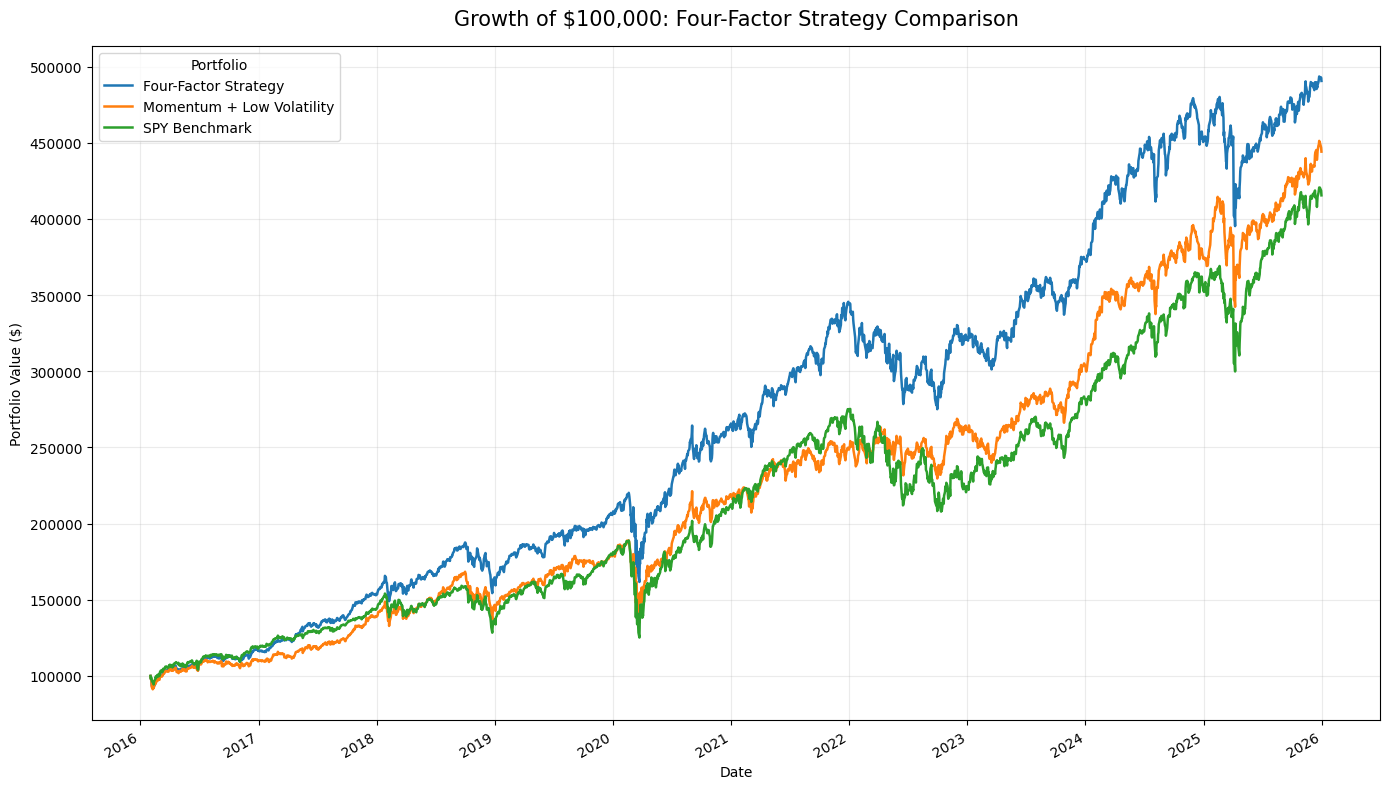

Common-period performance summary:


,Four-Factor Strategy,Two-Factor Strategy,SPY Benchmark
Total Return,3.9059,3.4418,3.1549
CAGR,0.1740,0.1623,0.1545
Annualized Volatility,0.1692,0.1699,0.1796
Sharpe Ratio,0.9033,0.8413,0.7678
Sortino Ratio,1.1099,1.0320,0.9233
Maximum Drawdown,-0.2657,-0.2846,-0.3372
Calmar Ratio,0.6548,0.5703,0.4582
Annualized Alpha,0.0362,0.0302,NaN
Beta,0.8459,0.8173,NaN
Information Ratio,0.1883,0.0551,NaN


In [40]:
# ============================================================
# CELL 47: FOUR-FACTOR, TWO-FACTOR, AND SPY COMPARISON
# ============================================================

comparison_returns = pd.concat(
    [
        four_factor_results["Net Return"].rename(
            "Four-Factor Strategy"
        ),
        backtest_results["Net Return"].rename(
            "Momentum + Low Volatility"
        ),
        backtest_results["Benchmark Return"].rename(
            "SPY Benchmark"
        ),
    ],
    axis=1,
).dropna()


if comparison_returns.empty:
    raise ValueError(
        "No common evaluation period exists for the three portfolios."
    )


# Rebase every portfolio at the close of the first common date.
comparison_returns.iloc[0] = 0.0


comparison_nav = (
    CONFIG.initial_capital
    * (1.0 + comparison_returns).cumprod()
)


print("Common comparison period:")
print(
    f"{comparison_nav.index.min().date()} through "
    f"{comparison_nav.index.max().date()}"
)

print()
print("Final values over the common evaluation period:")

display(
    comparison_nav.iloc[-1]
    .rename("Final Portfolio Value")
    .to_frame()
)


ax = comparison_nav.plot(
    figsize=(14, 8),
    linewidth=1.8,
)

ax.set_title(
    "Growth of $100,000: Four-Factor Strategy Comparison",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(True, alpha=0.25)
ax.legend(title="Portfolio")

plt.tight_layout()
plt.show()


common_risk_free_rate = (
    daily_risk_free_rate
    .reindex(comparison_returns.index)
    .ffill()
    .bfill()
)


four_factor_common_metrics = calculate_performance_metrics(
    returns=comparison_returns["Four-Factor Strategy"],
    nav=comparison_nav["Four-Factor Strategy"],
    risk_free_returns=common_risk_free_rate,
    annualization_factor=CONFIG.annualization_factor,
    benchmark_returns=comparison_returns["SPY Benchmark"],
)


two_factor_common_metrics = calculate_performance_metrics(
    returns=comparison_returns["Momentum + Low Volatility"],
    nav=comparison_nav["Momentum + Low Volatility"],
    risk_free_returns=common_risk_free_rate,
    annualization_factor=CONFIG.annualization_factor,
    benchmark_returns=comparison_returns["SPY Benchmark"],
)


spy_common_metrics = calculate_performance_metrics(
    returns=comparison_returns["SPY Benchmark"],
    nav=comparison_nav["SPY Benchmark"],
    risk_free_returns=common_risk_free_rate,
    annualization_factor=CONFIG.annualization_factor,
    benchmark_returns=None,
)


full_comparison_metrics = pd.concat(
    [
        four_factor_common_metrics.rename(
            "Four-Factor Strategy"
        ),
        two_factor_common_metrics.rename(
            "Two-Factor Strategy"
        ),
        spy_common_metrics.rename(
            "SPY Benchmark"
        ),
    ],
    axis=1,
)


KEY_COMPARISON_METRICS = [
    "Total Return",
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Maximum Drawdown",
    "Calmar Ratio",
    "Annualized Alpha",
    "Beta",
    "Information Ratio",
]


print("Common-period performance summary:")

display(
    full_comparison_metrics.loc[
        KEY_COMPARISON_METRICS
    ]
)

## 10. Robustness Testing and Final Reporting

The core four-factor strategy is now complete.

This section evaluates whether the results are persistent across time, sensitive
to transaction-cost assumptions, and dependent on only a small number of
exceptional months.

The resulting reports will also be exported for the final GitHub repository.

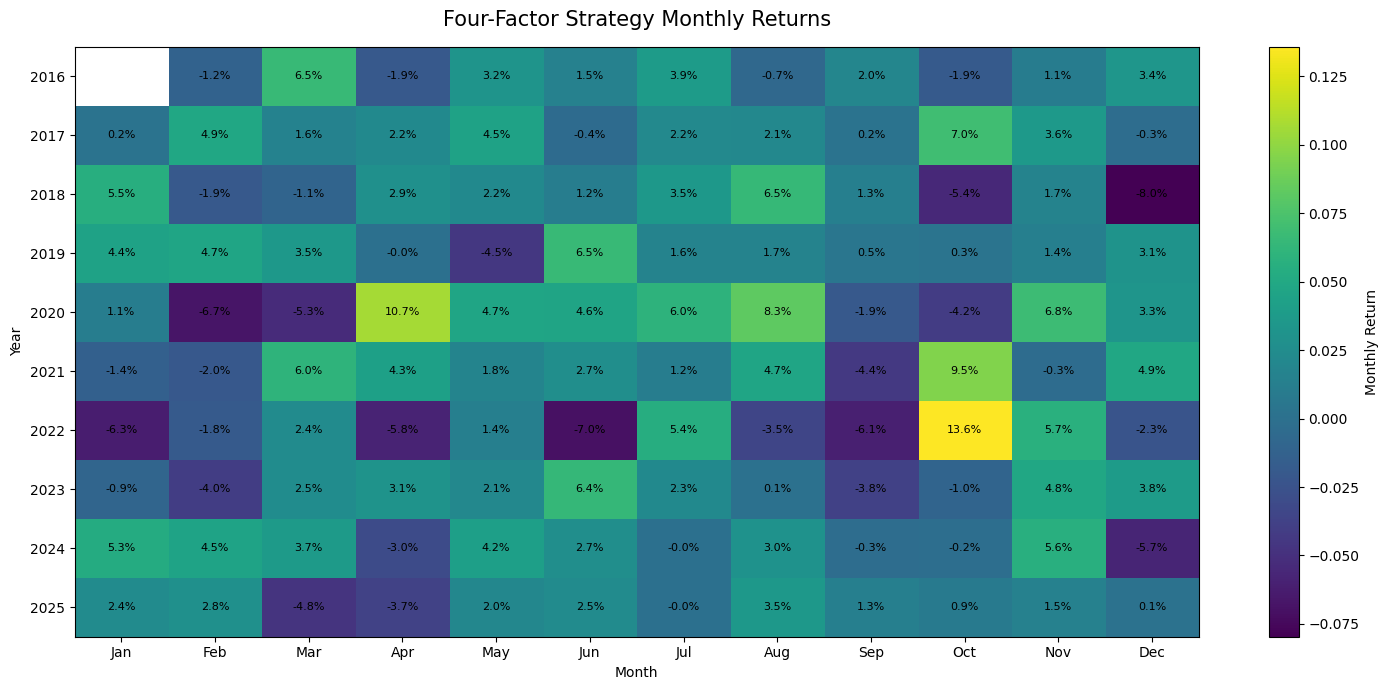

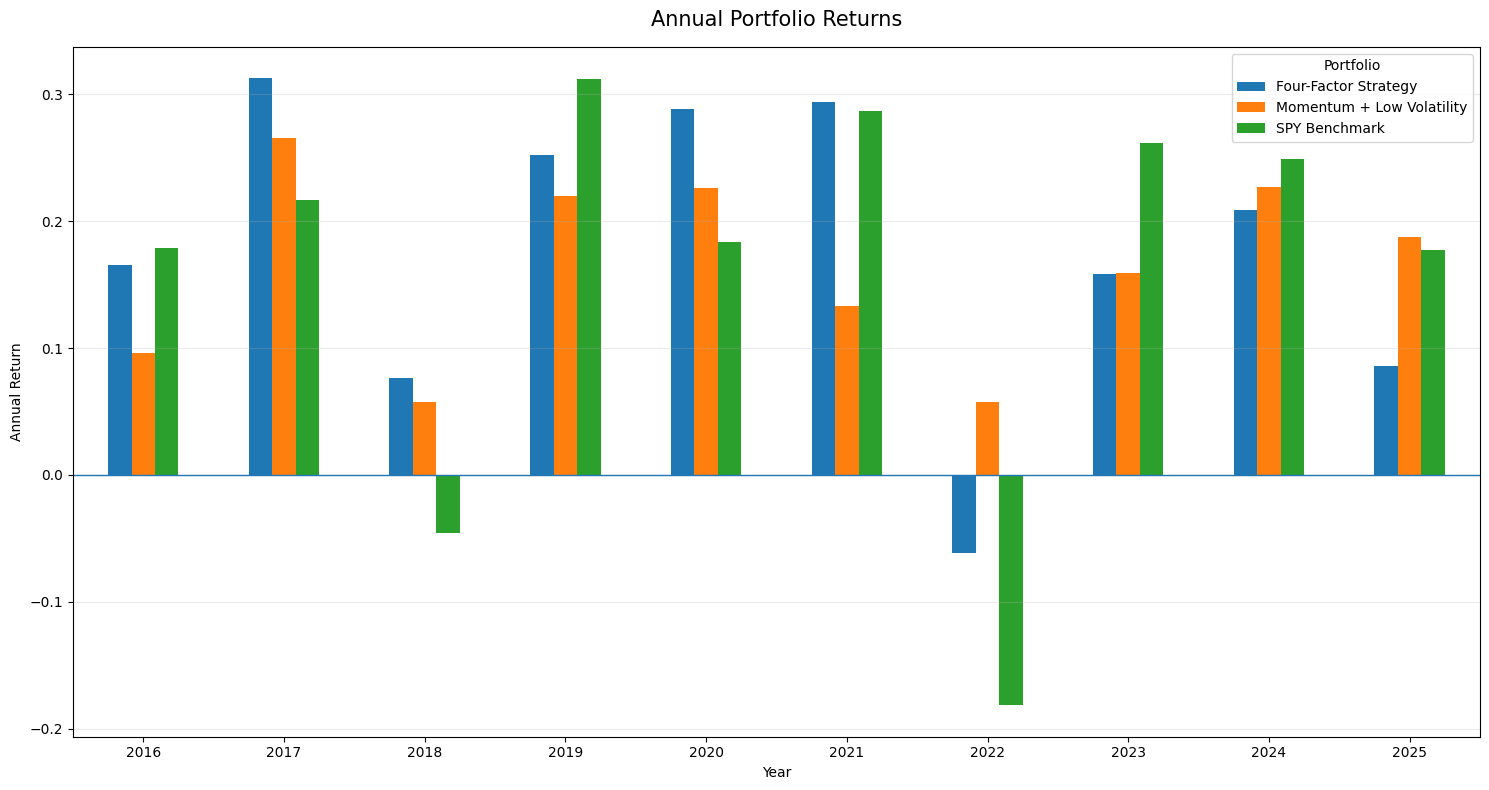

Annual-return comparison:


,Four-Factor Strategy,Momentum + Low Volatility,SPY Benchmark
Date,,,
2016,0.1651,0.0959,0.1791
2017,0.3128,0.2657,0.2171
2018,0.0768,0.0574,-0.0457
2019,0.2525,0.2197,0.3122
2020,0.2881,0.2258,0.1833
2021,0.2942,0.1335,0.2873
2022,-0.0619,0.0576,-0.1818
2023,0.1585,0.1592,0.2618
2024,0.2090,0.2270,0.2489


In [41]:
# ============================================================
# CELL 48: MONTHLY AND ANNUAL RETURN VISUALIZATIONS
# ============================================================

import calendar


four_factor_monthly_returns = (
    (1.0 + comparison_returns["Four-Factor Strategy"])
    .resample("ME")
    .prod()
    - 1.0
)


monthly_return_records = pd.DataFrame(
    {
        "Year": four_factor_monthly_returns.index.year,
        "Month": four_factor_monthly_returns.index.month,
        "Return": four_factor_monthly_returns.to_numpy(),
    }
)


monthly_return_table = (
    monthly_return_records
    .pivot(
        index="Year",
        columns="Month",
        values="Return",
    )
    .reindex(columns=range(1, 13))
)


# Monthly-return heatmap
fig, ax = plt.subplots(figsize=(15, 7))

heatmap = ax.imshow(
    monthly_return_table.to_numpy(),
    aspect="auto",
)

ax.set_title(
    "Four-Factor Strategy Monthly Returns",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticks(range(12))
ax.set_xticklabels(
    [calendar.month_abbr[month] for month in range(1, 13)]
)

ax.set_yticks(range(len(monthly_return_table.index)))
ax.set_yticklabels(monthly_return_table.index)


for row_position in range(monthly_return_table.shape[0]):
    for column_position in range(monthly_return_table.shape[1]):
        value = monthly_return_table.iloc[
            row_position,
            column_position,
        ]

        if pd.notna(value):
            ax.text(
                column_position,
                row_position,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=8,
            )


fig.colorbar(
    heatmap,
    ax=ax,
    label="Monthly Return",
)

plt.tight_layout()
plt.show()


# Annual-return comparison
annual_return_comparison = (
    (1.0 + comparison_returns)
    .resample("YE")
    .prod()
    - 1.0
)

annual_return_comparison.index = (
    annual_return_comparison.index.year
)


ax = annual_return_comparison.plot(
    kind="bar",
    figsize=(15, 8),
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Annual Portfolio Returns",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Year")
ax.set_ylabel("Annual Return")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Portfolio")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


print("Annual-return comparison:")

display(annual_return_comparison)

In [42]:
# ============================================================
# CELL 49: SUBPERIOD ROBUSTNESS ANALYSIS
# ============================================================

SUBPERIODS = {
    "2016–2019": (
        "2016-01-01",
        "2019-12-31",
    ),
    "2020–2022": (
        "2020-01-01",
        "2022-12-31",
    ),
    "2023–2025": (
        "2023-01-01",
        "2025-12-31",
    ),
}


subperiod_records = []


for period_name, (
    period_start,
    period_end,
) in SUBPERIODS.items():

    period_returns = (
        comparison_returns
        .loc[period_start:period_end]
        .copy()
    )

    if len(period_returns) < 60:
        print(
            f"Skipping {period_name}: insufficient observations."
        )
        continue

    # Rebase all portfolios on the first date of each subperiod.
    period_returns.iloc[0] = 0.0

    period_nav = (
        CONFIG.initial_capital
        * (1.0 + period_returns).cumprod()
    )

    period_risk_free = (
        daily_risk_free_rate
        .reindex(period_returns.index)
        .ffill()
        .bfill()
    )

    for portfolio_name in period_returns.columns:

        benchmark_for_regression = (
            period_returns["SPY Benchmark"]
            if portfolio_name != "SPY Benchmark"
            else None
        )

        period_metrics = calculate_performance_metrics(
            returns=period_returns[portfolio_name],
            nav=period_nav[portfolio_name],
            risk_free_returns=period_risk_free,
            annualization_factor=CONFIG.annualization_factor,
            benchmark_returns=benchmark_for_regression,
        )

        subperiod_records.append(
            {
                "Period": period_name,
                "Portfolio": portfolio_name,
                "CAGR": period_metrics["CAGR"],
                "Annualized Volatility": period_metrics[
                    "Annualized Volatility"
                ],
                "Sharpe Ratio": period_metrics["Sharpe Ratio"],
                "Maximum Drawdown": period_metrics[
                    "Maximum Drawdown"
                ],
                "Annualized Alpha": period_metrics[
                    "Annualized Alpha"
                ],
            }
        )


subperiod_performance = pd.DataFrame(
    subperiod_records
)


subperiod_performance_table = (
    subperiod_performance
    .set_index(
        [
            "Period",
            "Portfolio",
        ]
    )
    .sort_index()
)


print("Subperiod robustness results:")

display(subperiod_performance_table)

Subperiod robustness results:


CAGR  Annualized Volatility  Sharpe Ratio  Maximum Drawdown  Annualized Alpha
Period    Portfolio                                                                                                
2016–2019 Four-Factor Strategy      0.2033                 0.1269        1.4146           -0.1772            0.0483
          Momentum + Low Volatility 0.1603                 0.1334        1.0794           -0.1852            0.0117
          SPY Benchmark             0.1616                 0.1257        1.1470           -0.1935               NaN
2020–2022 Four-Factor Strategy      0.1578                 0.2335        0.7080           -0.2657            0.0850
          Momentum + Low Volatility 0.1344                 0.2283        0.6297           -0.2846            0.0682
          SPY Benchmark             0.0730                 0.2499        0.3741           -0.3372               NaN
2023–2025 Four-Factor Strategy      0.1534                 0.1381        0.7601           -0.1766           -0.0254
          Momentum + Low Volatility 0.1949                 0.1415        0.9954           -0.1741            0.0109
          SPY Benchmark             0.2311                 0.1534        1.1246           -0.1876               NaN

Transaction-cost sensitivity:


,Final Portfolio Value,CAGR,Sharpe Ratio,Maximum Drawdown
Transaction Cost (bps),,,,
0,"512,326.2821",0.1792,0.9292,-0.2654
5,"501,090.8951",0.1766,0.9160,-0.2656
10,"490,099.4048",0.1740,0.9027,-0.2657
25,"458,536.4643",0.1663,0.8629,-0.2662
50,"410,341.7308",0.1536,0.7963,-0.2670


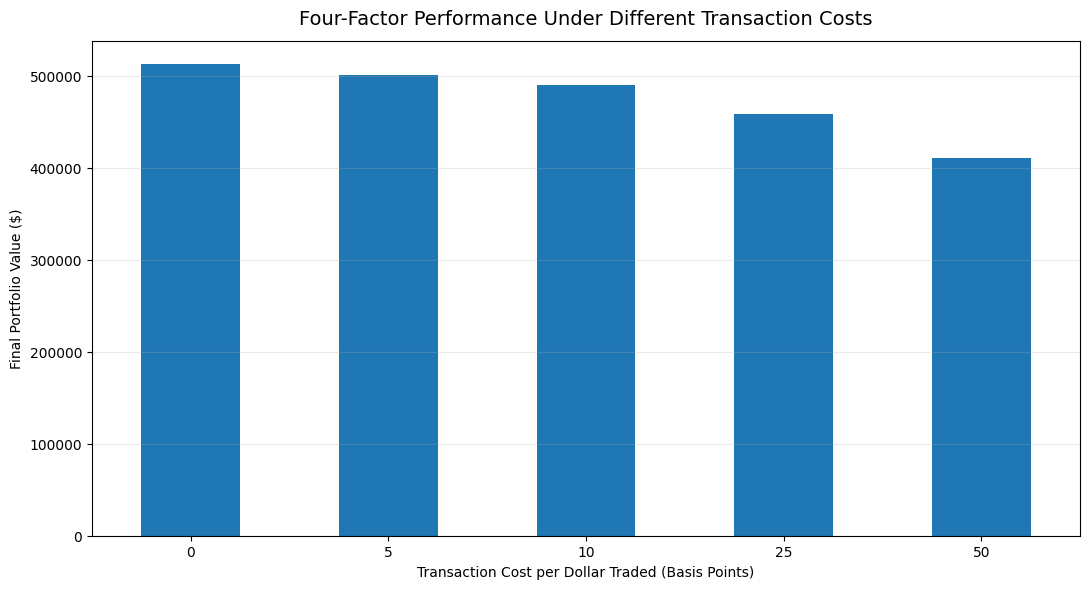

In [43]:
# ============================================================
# CELL 50: TRANSACTION-COST SENSITIVITY ANALYSIS
# ============================================================

TRANSACTION_COST_SCENARIOS = [
    0,
    5,
    10,
    25,
    50,
]


transaction_cost_records = []


for cost_bps in TRANSACTION_COST_SCENARIOS:

    sensitivity_output = run_drifted_weight_backtest(
        asset_returns=stock_returns,
        target_weights=four_factor_executed_weights,
        benchmark_returns=benchmark_returns,
        initial_capital=CONFIG.initial_capital,
        transaction_cost_bps=cost_bps,
        end_date=CONFIG.backtest_end,
    )

    sensitivity_results = sensitivity_output[
        "daily_results"
    ]

    sensitivity_risk_free = (
        daily_risk_free_rate
        .reindex(sensitivity_results.index)
        .ffill()
        .bfill()
    )

    sensitivity_metrics = calculate_performance_metrics(
        returns=sensitivity_results["Net Return"],
        nav=sensitivity_results["Strategy NAV"],
        risk_free_returns=sensitivity_risk_free,
        annualization_factor=CONFIG.annualization_factor,
        benchmark_returns=sensitivity_results[
            "Benchmark Return"
        ],
    )

    transaction_cost_records.append(
        {
            "Transaction Cost (bps)": cost_bps,
            "Final Portfolio Value": sensitivity_results[
                "Strategy NAV"
            ].iloc[-1],
            "CAGR": sensitivity_metrics["CAGR"],
            "Sharpe Ratio": sensitivity_metrics[
                "Sharpe Ratio"
            ],
            "Maximum Drawdown": sensitivity_metrics[
                "Maximum Drawdown"
            ],
        }
    )


transaction_cost_sensitivity = (
    pd.DataFrame(transaction_cost_records)
    .set_index("Transaction Cost (bps)")
)


print("Transaction-cost sensitivity:")

display(transaction_cost_sensitivity)


ax = transaction_cost_sensitivity[
    "Final Portfolio Value"
].plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title(
    "Four-Factor Performance Under Different Transaction Costs",
    fontsize=14,
    pad=12,
)

ax.set_xlabel("Transaction Cost per Dollar Traded (Basis Points)")
ax.set_ylabel("Final Portfolio Value ($)")
ax.grid(True, axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

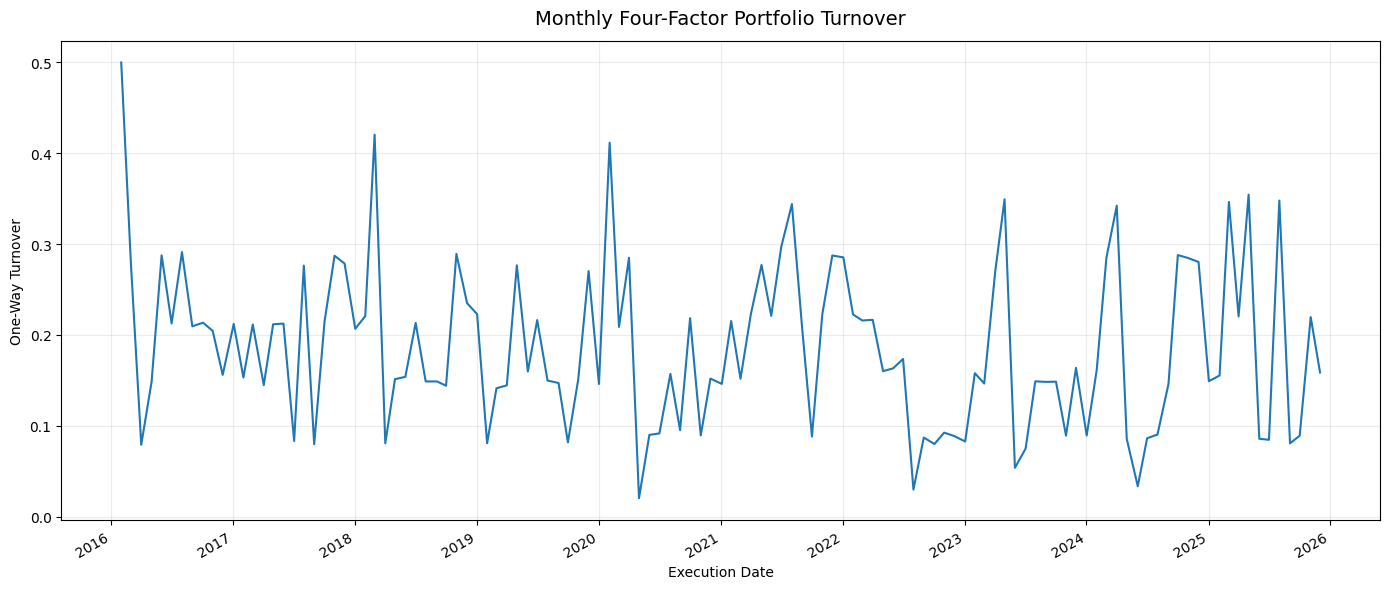

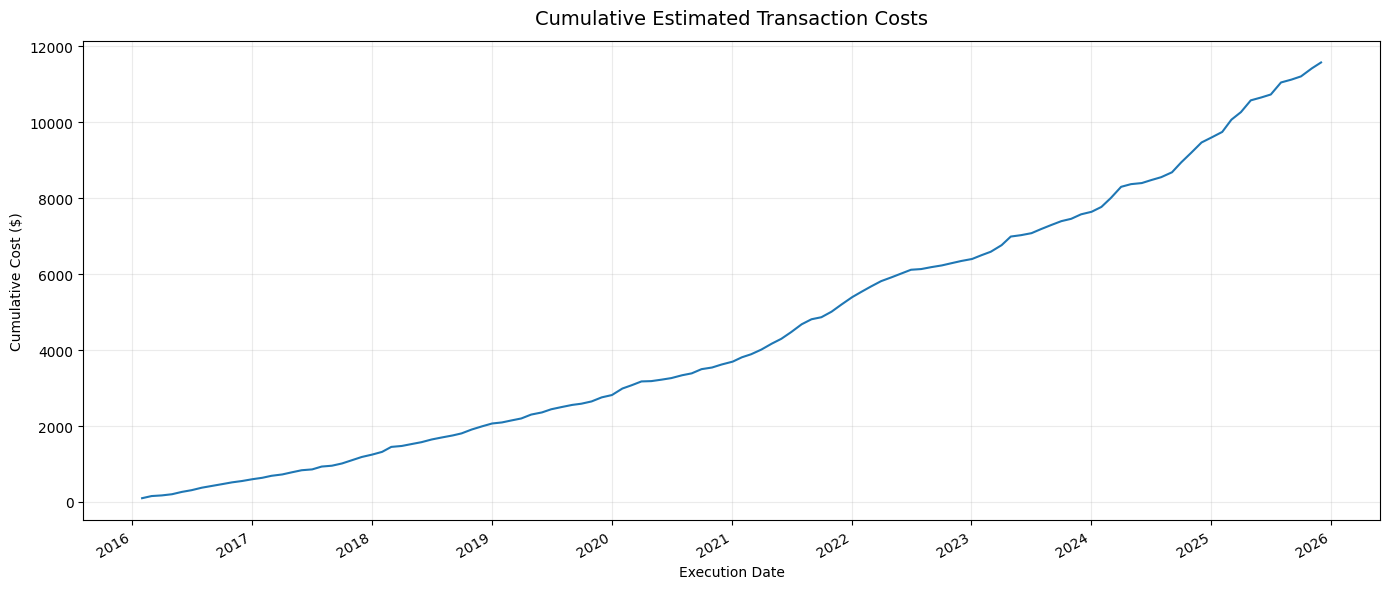

Average monthly one-way turnover: 18.63%
Median monthly one-way turnover: 16.02%
Total estimated transaction costs: $11,574.86


In [44]:
# ============================================================
# CELL 51: PORTFOLIO TURNOVER AND TRADING-COST DIAGNOSTICS
# ============================================================

four_factor_turnover = (
    four_factor_rebalance_log[
        "One-Way Turnover"
    ]
)

cumulative_transaction_costs = (
    four_factor_rebalance_log[
        "Transaction Cost Dollars"
    ]
    .cumsum()
)


ax = four_factor_turnover.plot(
    figsize=(14, 6),
    linewidth=1.5,
)

ax.set_title(
    "Monthly Four-Factor Portfolio Turnover",
    fontsize=14,
    pad=12,
)

ax.set_xlabel("Execution Date")
ax.set_ylabel("One-Way Turnover")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


ax = cumulative_transaction_costs.plot(
    figsize=(14, 6),
    linewidth=1.5,
)

ax.set_title(
    "Cumulative Estimated Transaction Costs",
    fontsize=14,
    pad=12,
)

ax.set_xlabel("Execution Date")
ax.set_ylabel("Cumulative Cost ($)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


print(
    "Average monthly one-way turnover: "
    f"{four_factor_turnover.mean():.2%}"
)

print(
    "Median monthly one-way turnover: "
    f"{four_factor_turnover.median():.2%}"
)

print(
    "Total estimated transaction costs: "
    f"${four_factor_rebalance_log['Transaction Cost Dollars'].sum():,.2f}"
)


In [45]:
# ============================================================
# CELL 52: LATEST FOUR-FACTOR PORTFOLIO HOLDINGS
# ============================================================

LATEST_FOUR_FACTOR_DATE = (
    four_factor_target_weights.index[-1]
)


latest_four_factor_weights = (
    four_factor_target_weights.loc[
        LATEST_FOUR_FACTOR_DATE
    ]
)


latest_four_factor_tickers = (
    latest_four_factor_weights[
        latest_four_factor_weights > 0
    ].index
)


latest_four_factor_portfolio = pd.DataFrame(
    {
        "Composite Score": four_factor_composite_score.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Composite Rank": four_factor_ranks.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Momentum Z-Score": momentum_zscore.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Value Z-Score": value_factor_zscore.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Quality Z-Score": quality_factor_zscore.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Low-Volatility Z-Score": low_volatility_zscore.loc[
            LATEST_FOUR_FACTOR_DATE,
            latest_four_factor_tickers,
        ],
        "Target Weight": latest_four_factor_weights.loc[
            latest_four_factor_tickers
        ],
    }
)


latest_four_factor_portfolio = (
    latest_four_factor_portfolio
    .sort_values("Composite Rank")
)

latest_four_factor_portfolio.index.name = "Ticker"


print(
    "Latest selected four-factor portfolio: "
    f"{LATEST_FOUR_FACTOR_DATE.strftime('%Y-%m-%d')}"
)

display(latest_four_factor_portfolio)

Latest selected four-factor portfolio: 2025-12-31


,Composite Score,Composite Rank,Momentum Z-Score,Value Z-Score,Quality Z-Score,Low-Volatility Z-Score,Target Weight
Ticker,,,,,,,
XOM,0.8820,1.0000,0.0056,1.5714,0.8697,1.0814,0.0667
CVX,0.7901,2.0000,-0.1114,1.3378,0.8080,1.1261,0.0667
JNJ,0.5317,3.0000,1.4018,-0.3206,-0.1202,1.1659,0.0667
NFLX,0.4727,4.0000,0.2946,1.9210,0.9609,-1.2856,0.0667
MRK,0.3661,5.0000,-0.3602,1.0661,0.9156,-0.1574,0.0667
COP,0.3553,6.0000,-0.7369,1.8347,0.6323,-0.3089,0.0667
BAC,0.3445,7.0000,0.3797,1.9210,-1.6296,0.7069,0.0667
AAPL,0.3075,8.0000,-0.0931,-0.8399,1.0929,1.0702,0.0667
MSFT,0.2998,9.0000,0.0202,-0.7695,1.0702,0.8783,0.0667


## 11. Interpretation and Limitations

This notebook demonstrates a complete quantitative-research workflow, but its
historical results should not be interpreted as a live investment forecast.

Important limitations include:

- **Survivorship and selection bias:** the research universe is a fixed list of
  large companies selected with present-day knowledge.
- **Simplified execution:** trades are modeled at daily closing prices without
  bid–ask spreads, market impact, taxes, or liquidity constraints beyond a
  fixed transaction-cost assumption.
- **Annual fundamentals:** the model primarily uses annual SEC filings rather
  than a fully standardized trailing-twelve-month quarterly pipeline.
- **Industry comparability:** financial companies and non-financial companies
  report some accounting concepts differently.
- **No sector neutrality:** factor rankings may create unintended sector bets.
- **Data-source limitations:** Yahoo Finance is convenient for educational
  research but is not an institutional market-data feed.
- **In-sample design risk:** factor definitions, portfolio size, and weighting
  choices were evaluated on the same historical period shown in the results.

A stronger production version would use a historical constituent database,
quarterly point-in-time fundamentals, sector-neutral ranking, corporate-action
validation, and a fully held-out out-of-sample test.


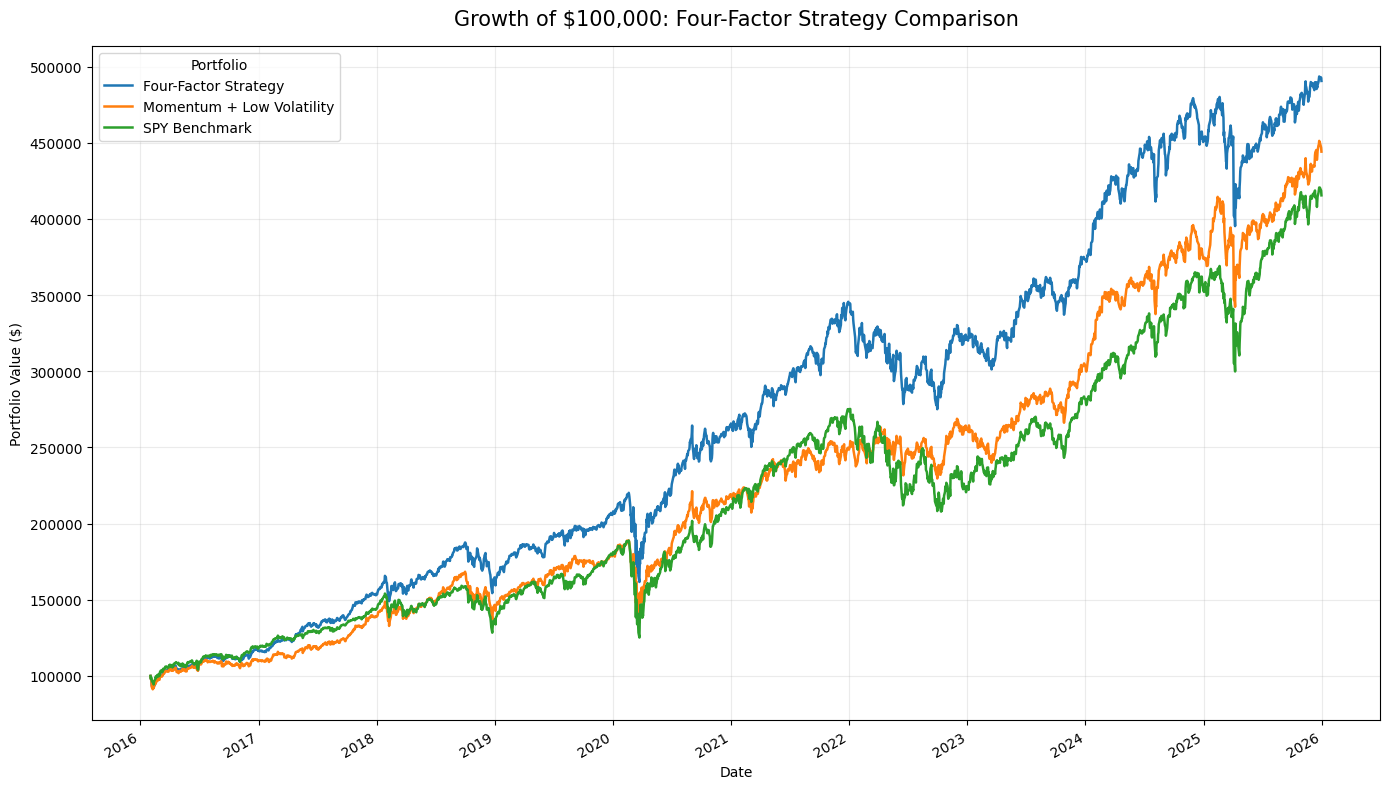

Project outputs exported successfully.
Output folder: /content/multi_factor_project_outputs
ZIP archive: /content/multi_factor_project_outputs.zip


In [46]:
# ============================================================
# CELL 53: EXPORT FINAL RESULTS
# ============================================================

from pathlib import Path
import shutil


OUTPUT_DIRECTORY = Path(
    "/content/multi_factor_project_outputs"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


comparison_nav.to_csv(
    OUTPUT_DIRECTORY / "portfolio_equity_curves.csv"
)

full_comparison_metrics.to_csv(
    OUTPUT_DIRECTORY / "performance_metrics.csv"
)

four_factor_rebalance_log.to_csv(
    OUTPUT_DIRECTORY / "four_factor_rebalance_log.csv"
)

latest_four_factor_portfolio.to_csv(
    OUTPUT_DIRECTORY / "latest_portfolio_holdings.csv"
)

monthly_return_table.to_csv(
    OUTPUT_DIRECTORY / "monthly_return_heatmap_data.csv"
)

annual_return_comparison.to_csv(
    OUTPUT_DIRECTORY / "annual_returns.csv"
)

subperiod_performance_table.to_csv(
    OUTPUT_DIRECTORY / "subperiod_performance.csv"
)

transaction_cost_sensitivity.to_csv(
    OUTPUT_DIRECTORY / "transaction_cost_sensitivity.csv"
)


# Save the primary comparison chart.
ax = comparison_nav.plot(
    figsize=(14, 8),
    linewidth=1.8,
)

ax.set_title(
    "Growth of $100,000: Four-Factor Strategy Comparison",
    fontsize=15,
    pad=15,
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(True, alpha=0.25)
ax.legend(title="Portfolio")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "portfolio_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


ZIP_BASE_PATH = "/content/multi_factor_project_outputs"

shutil.make_archive(
    ZIP_BASE_PATH,
    "zip",
    OUTPUT_DIRECTORY,
)


print("Project outputs exported successfully.")
print(f"Output folder: {OUTPUT_DIRECTORY}")
print(f"ZIP archive: {ZIP_BASE_PATH}.zip")

In [47]:
from google.colab import files

files.download(
    "/content/multi_factor_project_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>